In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import pacf
from xgboost import XGBRegressor
import re
from sklearn.cluster import KMeans
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from entsoe import EntsoePandasClient
#from entsoe.mappings import AREA_MAPPINGS
import requests
import os
# Set proxy for this Python session
os.environ['HTTP_PROXY'] = 'http://172.30.10.11:3128'
os.environ['HTTPS_PROXY'] = 'http://172.30.10.11:3128'

In [97]:
def make_lags(ts, lagfirst, laglast):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lagfirst, laglast + 1)
        },
        axis=1)

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'

C:\Users\as comp\miniconda3\lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [3]:
a = pd.read_csv("C:/Users/as comp/Downloads/AT_2020.csv")
b = pd.read_csv("C:/Users/as comp/Downloads/AT_2021.csv")
c = pd.read_csv("C:/Users/as comp/Downloads/AT_2022.csv")
d = pd.read_csv("C:/Users/as comp/Downloads/AT_2023.csv")
e = pd.read_csv("C:/Users/as comp/Downloads/AT_2024.csv")

In [4]:
data = pd.concat([d,e], axis = 0)

In [59]:
data

,MTU (CET/CEST),Area,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2023 00:00 - 01/01/2023 00:15,Austria (AT),5538.4,5672.0
1,01/01/2023 00:15 - 01/01/2023 00:30,Austria (AT),5493.2,5572.0
2,01/01/2023 00:30 - 01/01/2023 00:45,Austria (AT),5426.0,5476.0
3,01/01/2023 00:45 - 01/01/2023 01:00,Austria (AT),5370.0,5368.0
4,01/01/2023 01:00 - 01/01/2023 01:15,Austria (AT),5383.2,5396.0
...,...,...,...,...
35131,31/12/2024 22:45 - 31/12/2024 23:00,Austria (AT),6715.6,6736.0
35132,31/12/2024 23:00 - 31/12/2024 23:15,Austria (AT),6656.8,6636.0
35133,31/12/2024 23:15 - 31/12/2024 23:30,Austria (AT),6585.6,6536.0
35134,31/12/2024 23:30 - 31/12/2024 23:45,Austria (AT),6531.6,6400.0


In [60]:
data.describe()

,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
count,70176.000000,70176.00000
mean,6669.909148,6658.02166
std,1302.159964,1222.65335
min,4009.200000,3964.00000
25%,5607.600000,5652.00000
50%,6634.000000,6652.00000
75%,7545.600000,7513.00000
max,10381.200000,10008.00000


In [5]:
data.index = data['MTU (CET/CEST)'].astype(str).str.split(" - ").str[0]
data.index.rename('datetime', inplace = True)
data.drop(['Area'], axis=1, inplace = True)
data.drop(['MTU (CET/CEST)'], axis = 1, inplace = True)

In [6]:
data.index = data.index.str.replace(r"\s*\(.*?\)", "", regex=True)

In [7]:
data.index = pd.to_datetime(data.index, format = "%d/%m/%Y %H:%M")

In [8]:
data

,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
datetime,,
2023-01-01 00:00:00,5538.4,5672.0
2023-01-01 00:15:00,5493.2,5572.0
2023-01-01 00:30:00,5426.0,5476.0
2023-01-01 00:45:00,5370.0,5368.0
2023-01-01 01:00:00,5383.2,5396.0
...,...,...
2024-12-31 22:45:00,6715.6,6736.0
2024-12-31 23:00:00,6656.8,6636.0
2024-12-31 23:15:00,6585.6,6536.0


In [9]:
data2 = pd.read_csv("C:/Users/as comp/Downloads/F.csv")

In [ ]:
data2.index = data2['MTU (CET/CEST)'].astype(str).str.split(" - ").str[0]
data2.index.rename('datetime', inplace = True)
data2.drop(['Area'], axis=1, inplace = True)
data2.drop(['MTU (CET/CEST)'], axis = 1, inplace = True)

In [11]:
data2.index = data2.index.str.replace(r"\s*\(.*?\)", "", regex=True)

In [13]:
data2.index = pd.to_datetime(data2.index, format = "%d/%m/%Y %H:%M")

In [14]:
data2 = data2[data2.index.month<6]

In [15]:
data2

,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
datetime,,
2025-01-01 00:00:00,6475.60,6012.00
2025-01-01 00:15:00,6438.00,5936.00
2025-01-01 00:30:00,6407.60,5828.00
2025-01-01 00:45:00,6357.60,5752.00
2025-01-01 01:00:00,6325.60,5716.00
...,...,...
2025-05-31 22:45:00,5250.40,5816.00
2025-05-31 23:00:00,5142.00,5732.00
2025-05-31 23:15:00,4997.60,5616.00


<AxesSubplot:title={'center':'Five Years Load Plot'}, xlabel='datetime'>

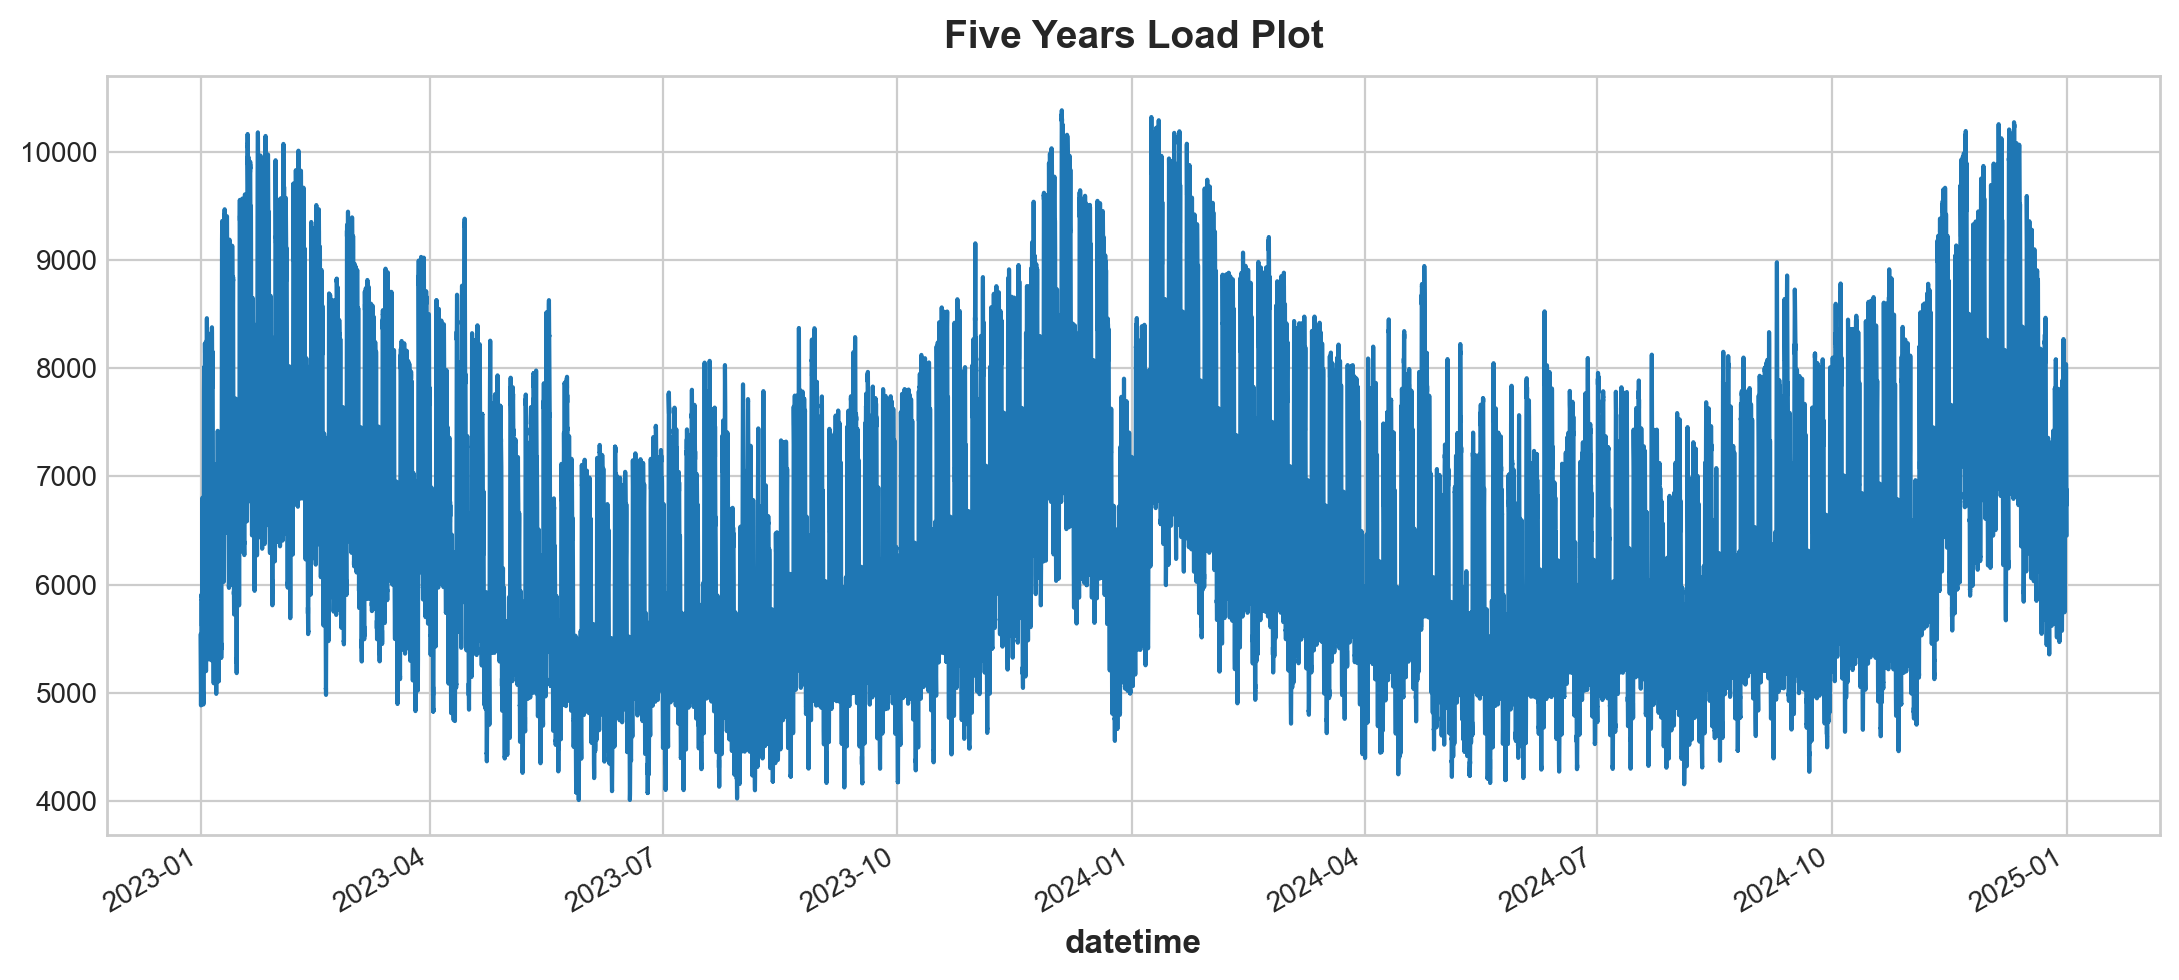

In [402]:
plt.figure()
data['Actual Total Load (MW)'].plot(title='Five Years Load Plot')

<AxesSubplot:title={'center':'Five Years Load Plot'}, xlabel='datetime'>

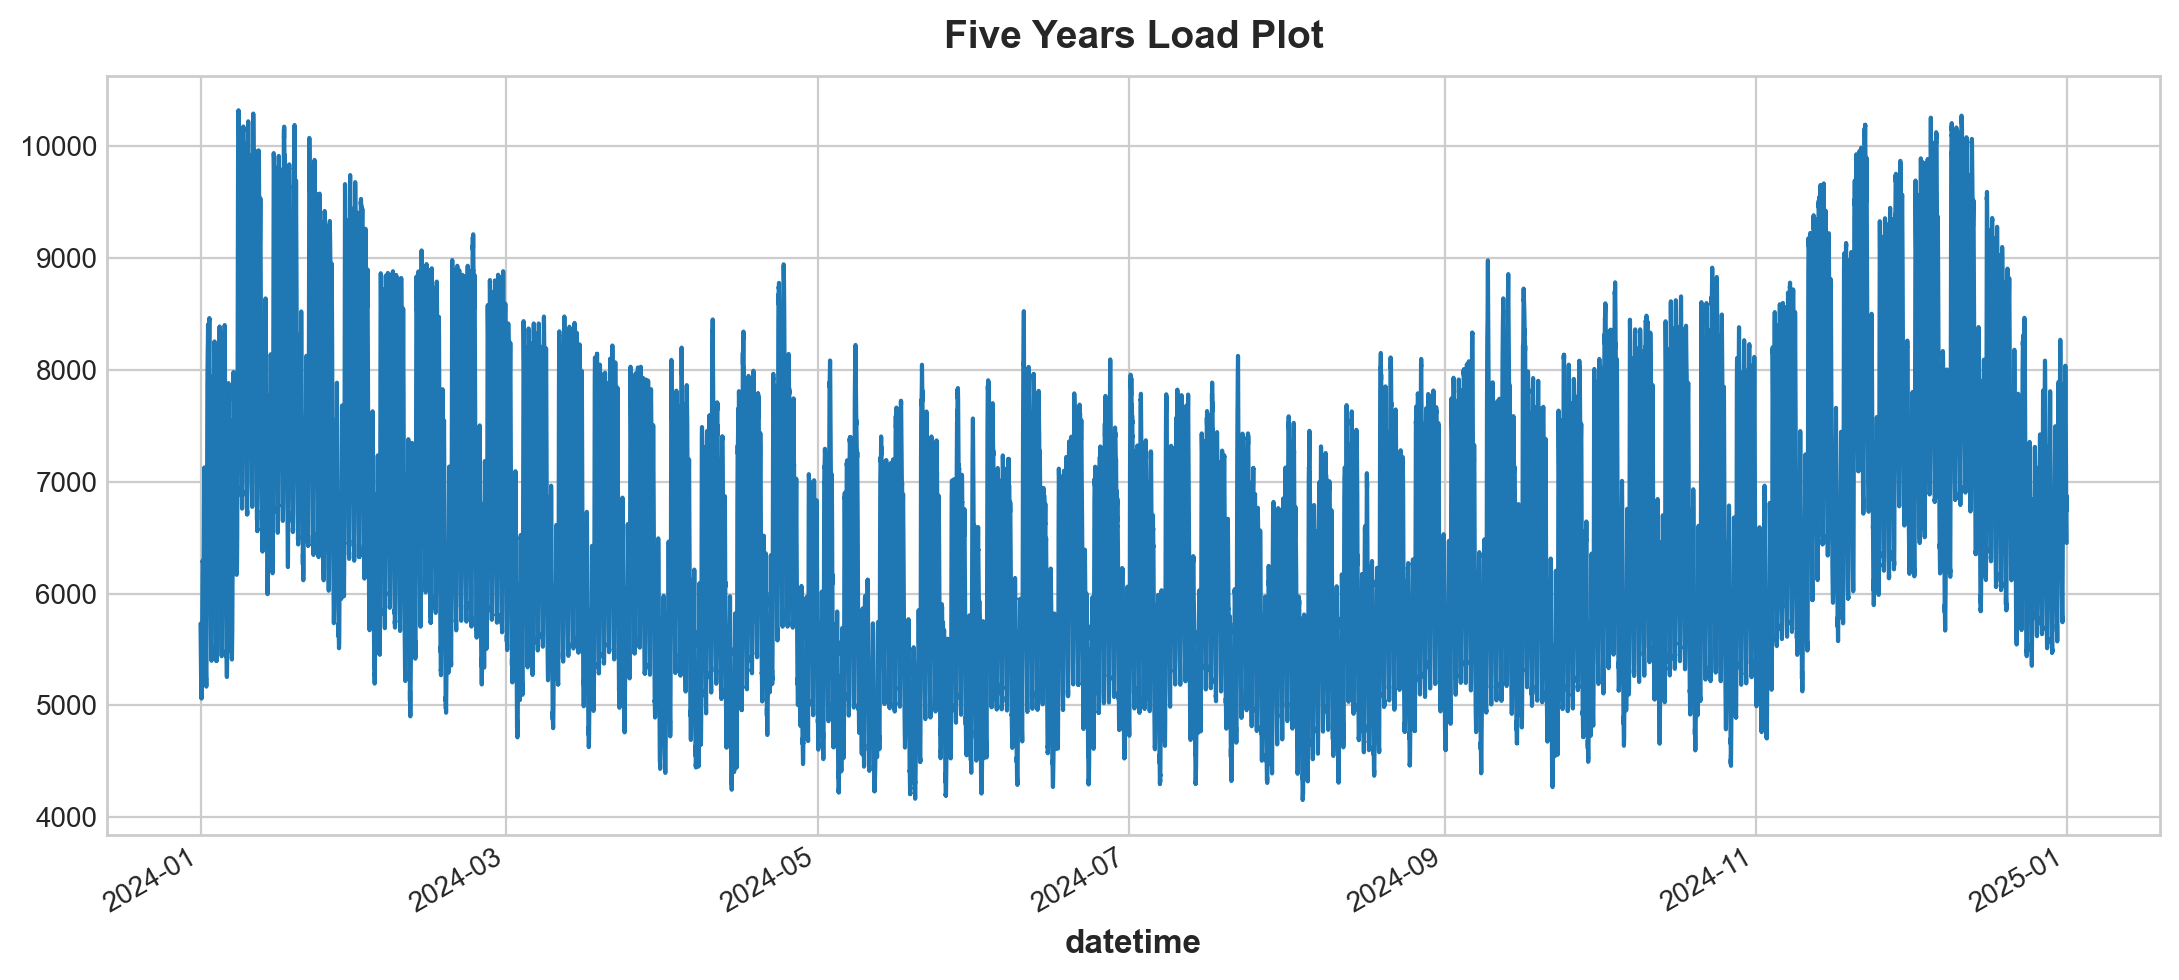

In [404]:
plt.figure()
data.loc['2024', 'Actual Total Load (MW)'].plot(title='Five Years Load Plot')

In [16]:
df = pd.read_csv("C:/Users/as comp/Downloads/weather.csv")

In [17]:
needed_columns = ["time", "tl", "rr", "so_h", "ff"]

df_small = df[needed_columns]

In [18]:
df_small["time"] = pd.to_datetime(df_small["time"])
df_small = df_small.set_index("time")

C:\Users\as comp\AppData\Local\Temp\ipykernel_13728\2725675196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small["time"] = pd.to_datetime(df_small["time"])


In [19]:
df_small.index = df_small.index.tz_localize(None)

In [20]:
df_small = df_small.rename(columns={
    "tl": "temp",
    "rr": "precip",
    "so_h": "sunshine",
    "ff": "windspee"
})

In [21]:
df_small

,temp,precip,sunshine,windspee
time,,,,
2023-01-01 00:00:00,4.8,0.0,0.0,2.2
2023-01-01 01:00:00,5.1,0.0,0.0,2.5
2023-01-01 02:00:00,4.6,0.0,0.0,2.3
2023-01-01 03:00:00,4.0,0.0,0.0,1.8
2023-01-01 04:00:00,3.5,0.0,0.0,1.2
...,...,...,...,...
2024-12-30 20:00:00,-2.4,0.0,0.0,1.0
2024-12-30 21:00:00,-3.3,0.0,0.0,0.8
2024-12-30 22:00:00,-3.3,0.0,0.0,0.6


In [22]:
weather_15 = df_small.resample("15min").interpolate()

In [23]:
weather_15.drop(weather_15.index[-1], inplace=True)

In [24]:
weather_15

,temp,precip,sunshine,windspee
time,,,,
2023-01-01 00:00:00,4.800,0.0,0.0,2.200
2023-01-01 00:15:00,4.875,0.0,0.0,2.275
2023-01-01 00:30:00,4.950,0.0,0.0,2.350
2023-01-01 00:45:00,5.025,0.0,0.0,2.425
2023-01-01 01:00:00,5.100,0.0,0.0,2.500
...,...,...,...,...
2024-12-30 22:45:00,-3.225,0.0,0.0,0.450
2024-12-30 23:00:00,-3.200,0.0,0.0,0.400
2024-12-30 23:15:00,-3.150,0.0,0.0,0.375


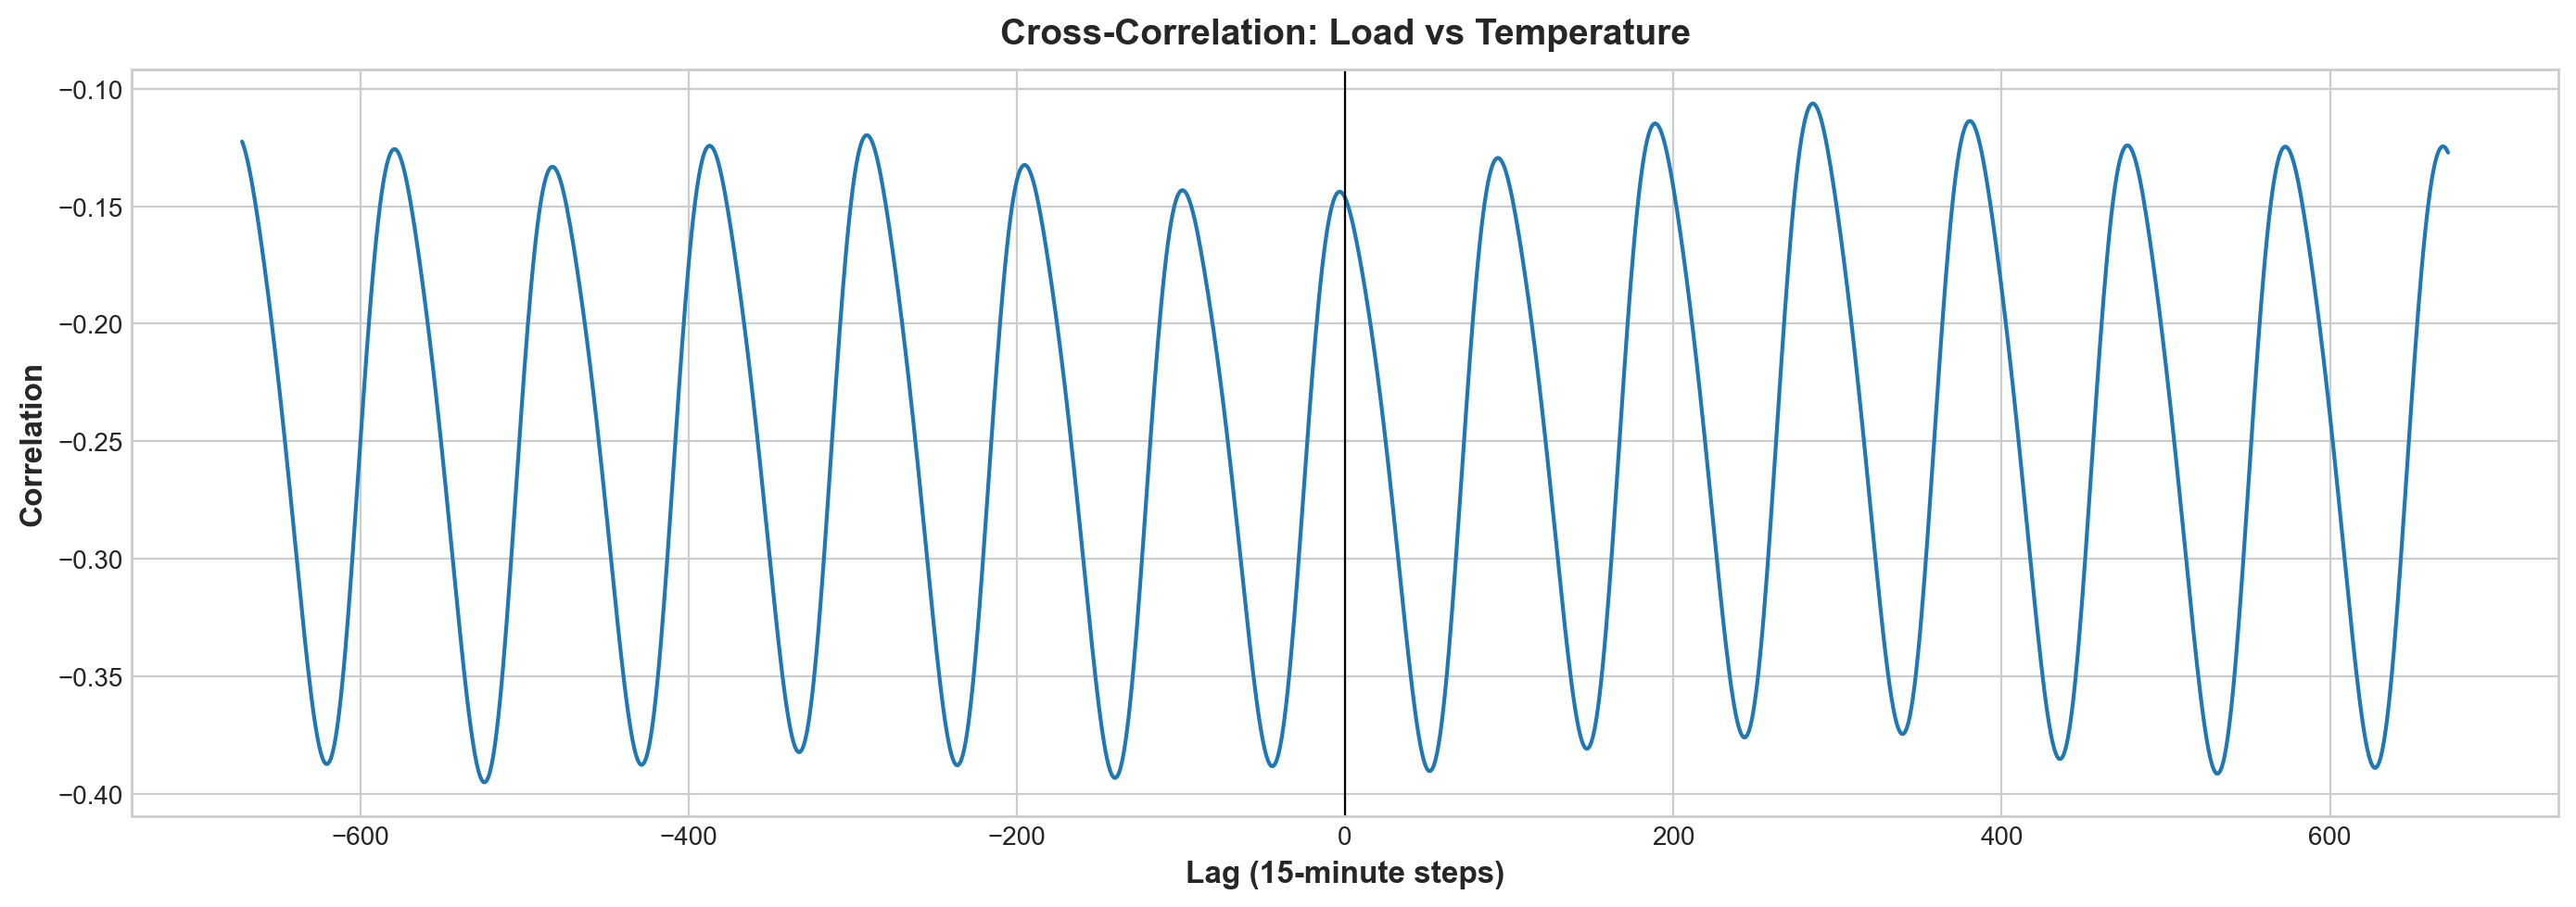

In [707]:
load = data['Actual Total Load (MW)']
temp = weather_15['temp']

# Number of lags: e.g., ±7 days of 15-min data
lags = 96 * 7

# Compute cross-correlation for each lag
ccf = [load.corr(temp.shift(lag)) for lag in range(-lags, lags+1)]

# Plot
plt.figure(figsize=(14,5))
plt.plot(range(-lags, lags+1), ccf)
plt.axvline(0, color='black', lw=0.8)
plt.title("Cross-Correlation: Load vs Temperature")
plt.xlabel("Lag (15-minute steps)")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()


In [25]:
df2 = pd.read_csv("C:/Users/as comp/Downloads/weather2.csv")
df_small2 = df2[needed_columns]
df_small2["time"] = pd.to_datetime(df_small2["time"])
df_small2 = df_small2.set_index("time")
df_small2.index = df_small2.index.tz_localize(None)
df_small2 = df_small2.rename(columns={
    "tl": "temp",
    "rr": "precip",
    "so_h": "sunshine",
    "ff": "windspeed"
})
weather2_15 = df_small2.resample("15min").interpolate()
weather2_15.drop(weather2_15.index[-1], inplace=True)

C:\Users\as comp\AppData\Local\Temp\ipykernel_13728\4078429764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small2["time"] = pd.to_datetime(df_small2["time"])


In [26]:
weather2_15

,temp,precip,sunshine,windspeed
time,,,,
2025-01-01 00:00:00,-6.100,0.0,0.0,0.100
2025-01-01 00:15:00,-6.150,0.0,0.0,0.150
2025-01-01 00:30:00,-6.200,0.0,0.0,0.200
2025-01-01 00:45:00,-6.250,0.0,0.0,0.250
2025-01-01 01:00:00,-6.300,0.0,0.0,0.300
...,...,...,...,...
2025-11-29 22:45:00,-1.275,0.0,0.0,0.200
2025-11-29 23:00:00,-1.300,0.0,0.0,0.200
2025-11-29 23:15:00,-1.275,0.0,0.0,0.175


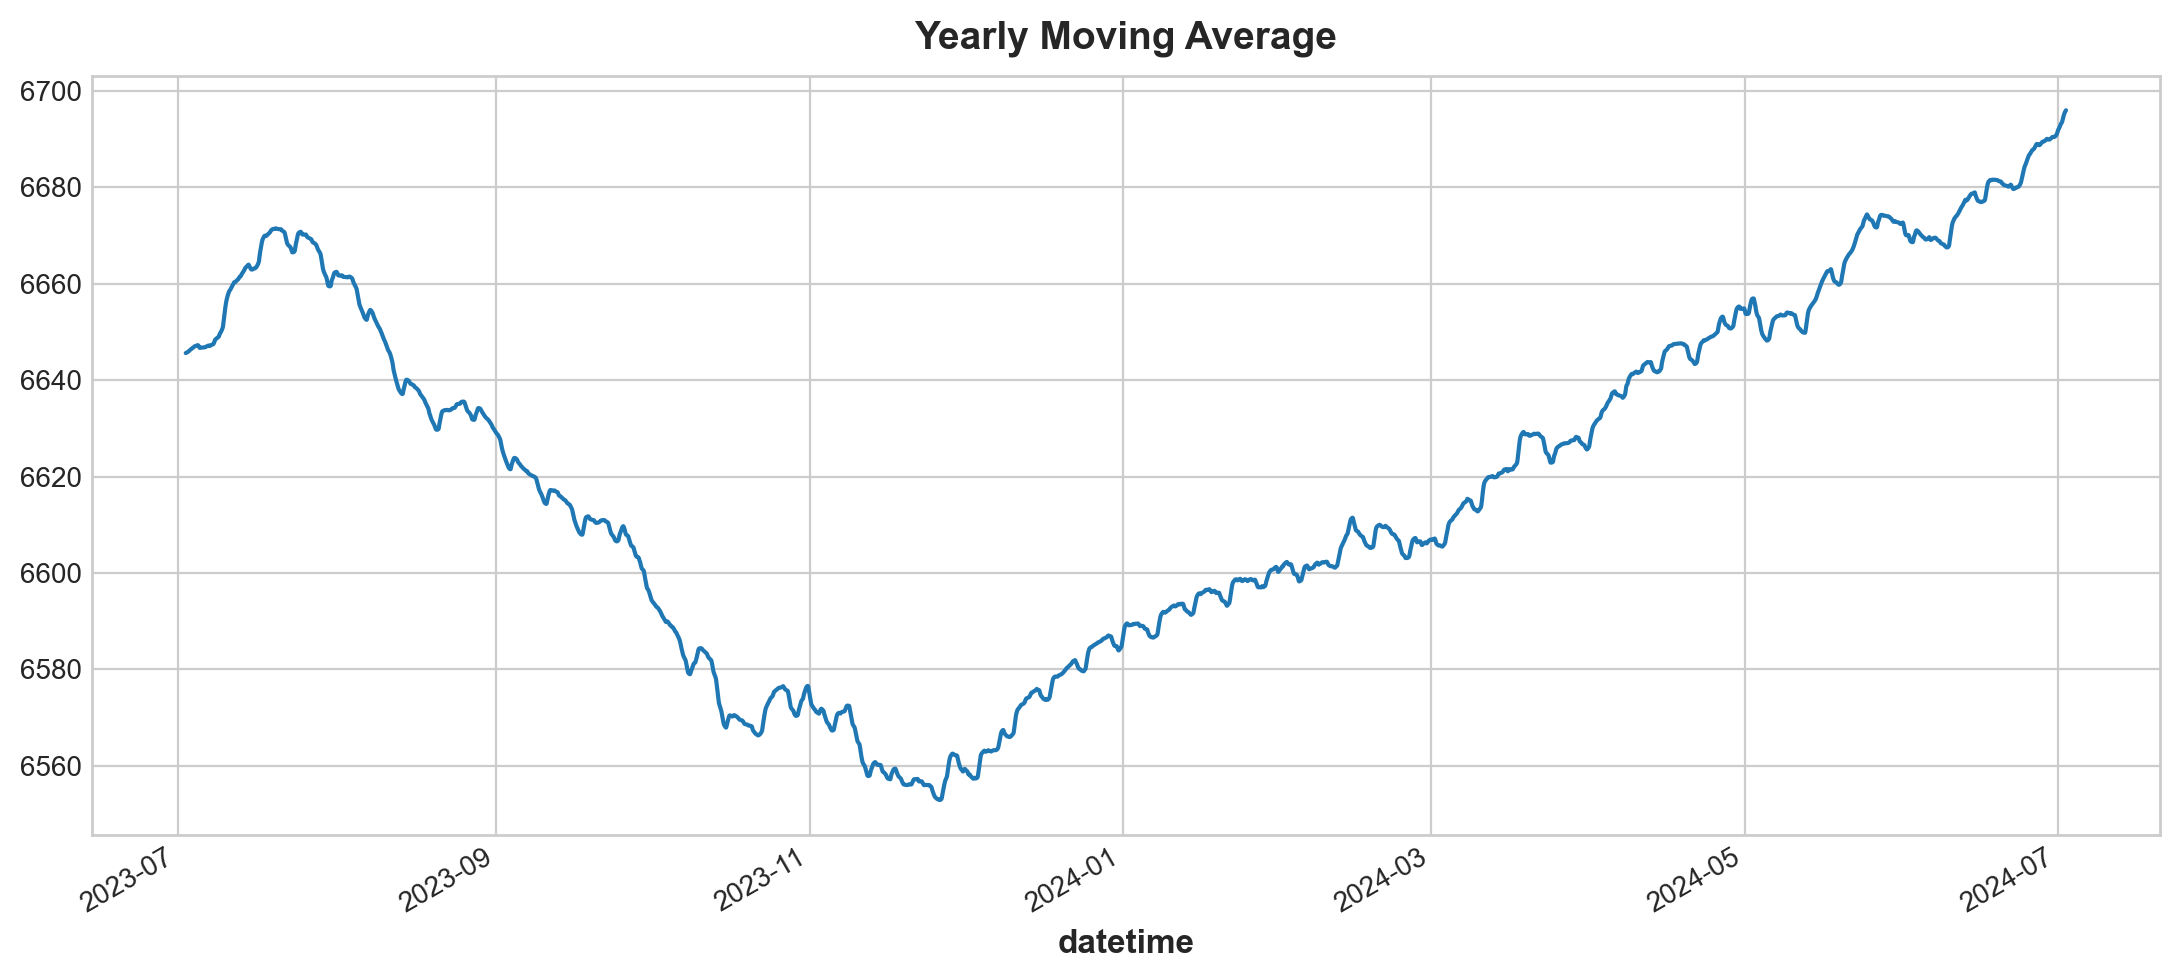

In [35]:
y_ma = data['Actual Total Load (MW)'].rolling(24*365*4,center=True).mean()


# Plot
ax = y_ma.plot()
ax.set_title("Yearly Moving Average");

In [36]:
from scipy.signal import periodogram

def plot_periodogram(ts, detrend='linear', ax=None):
    # Sampling frequency: 24 hours per day * 365 days per year
    fs = 24 * 4 * 365  # samples per year

    # Compute the periodogram
    freq, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum'
    )

    # Plot setup
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    ax.step(freq, spectrum, color="darkviolet", linewidth=1.5)
    ax.set_xscale("log")

    # X-axis ticks (in cycles per year)
    ax.set_xticks([1, 2, 4, 12, 52, 365, 730])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Monthly (12)",
            "Weekly (52)",
            "Daily (365)",
            "Twice Daily (730)"
        ],
        rotation=30
    )

    # Labels and title
    ax.set_ylabel("Strength", fontsize=11)
    ax.set_title("Periodogram (15 min Resolution Load Data)", fontsize=13)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    # Cosmetic improvements
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    return ax



<AxesSubplot:title={'center':'Periodogram (15 min Resolution Load Data)'}, ylabel='Strength'>

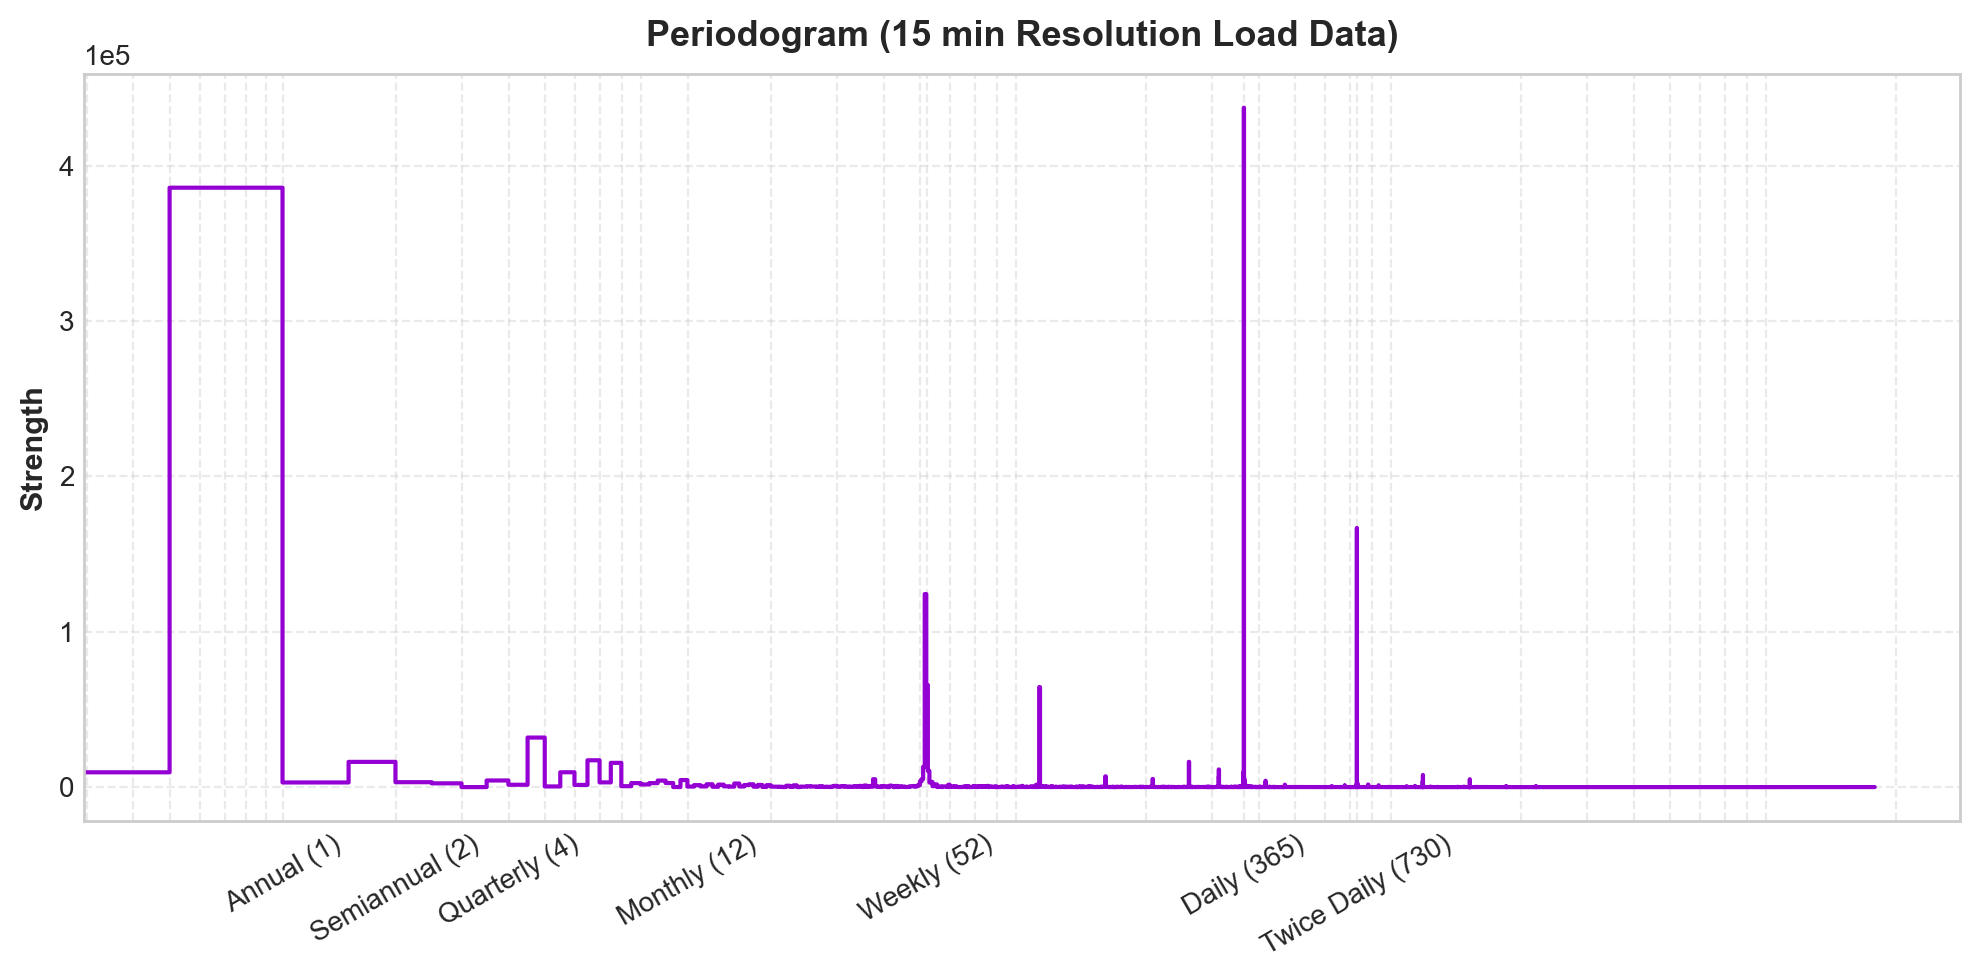

In [11]:
plot_periodogram(data['Actual Total Load (MW)'])

In [67]:
from statsmodels.tsa.seasonal import STL

stl = STL(data['Actual Total Load (MW)'], period=96)   # e.g. 96 for 15-min daily seasonality
res = stl.fit()

deseasonalized = data['Actual Total Load (MW)'] - res.seasonal

[Text(0.5, 1.0, 'load vs temp'),
 Text(0.5, 0, 'Load(MW)'),
 Text(0, 0.5, 'Temperature(°C)')]

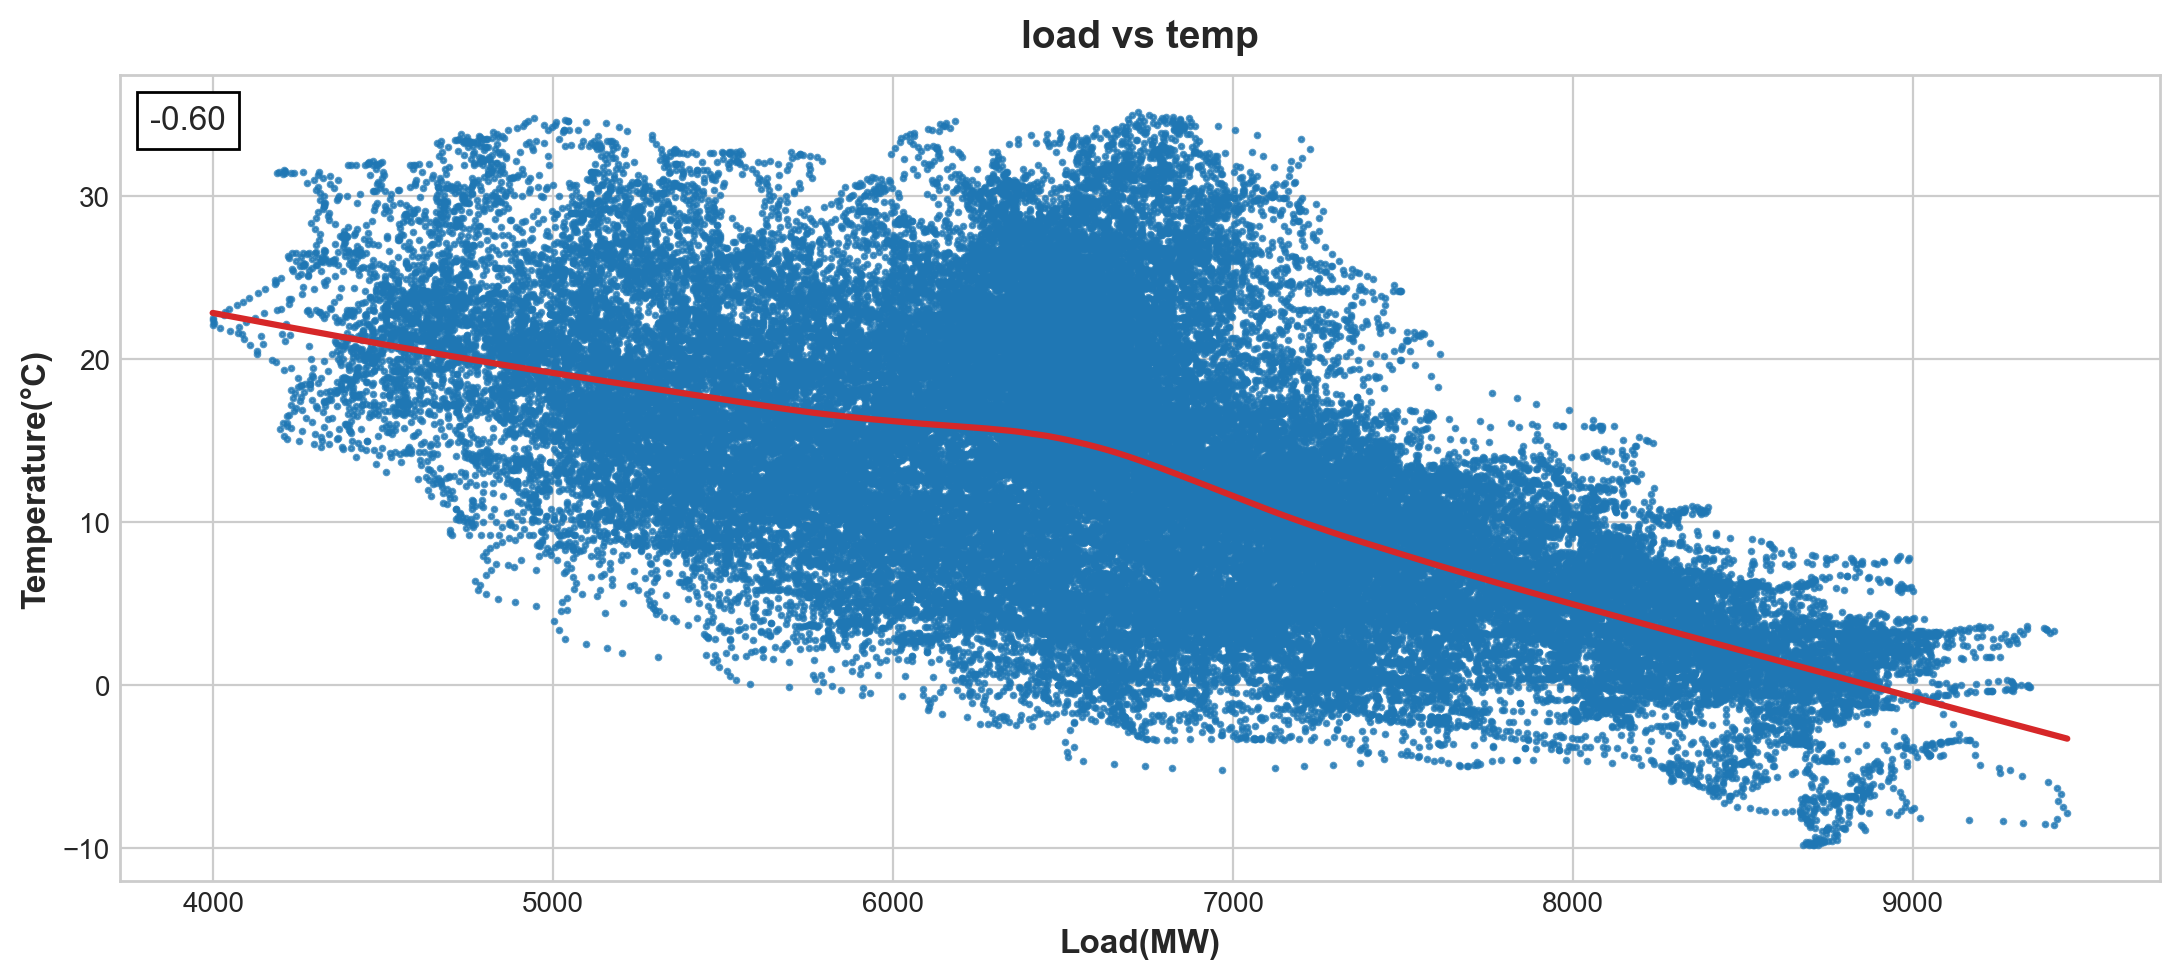

In [68]:
from matplotlib.offsetbox import AnchoredText
x_ = deseasonalized
y_ = weather_15['temp']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title='load vs temp', xlabel='Load(MW)', ylabel='Temperature(°C)')

[Text(0.5, 1.0, 'load vs temp'), Text(0.5, 0, ''), Text(0, 0.5, 'sunshine')]

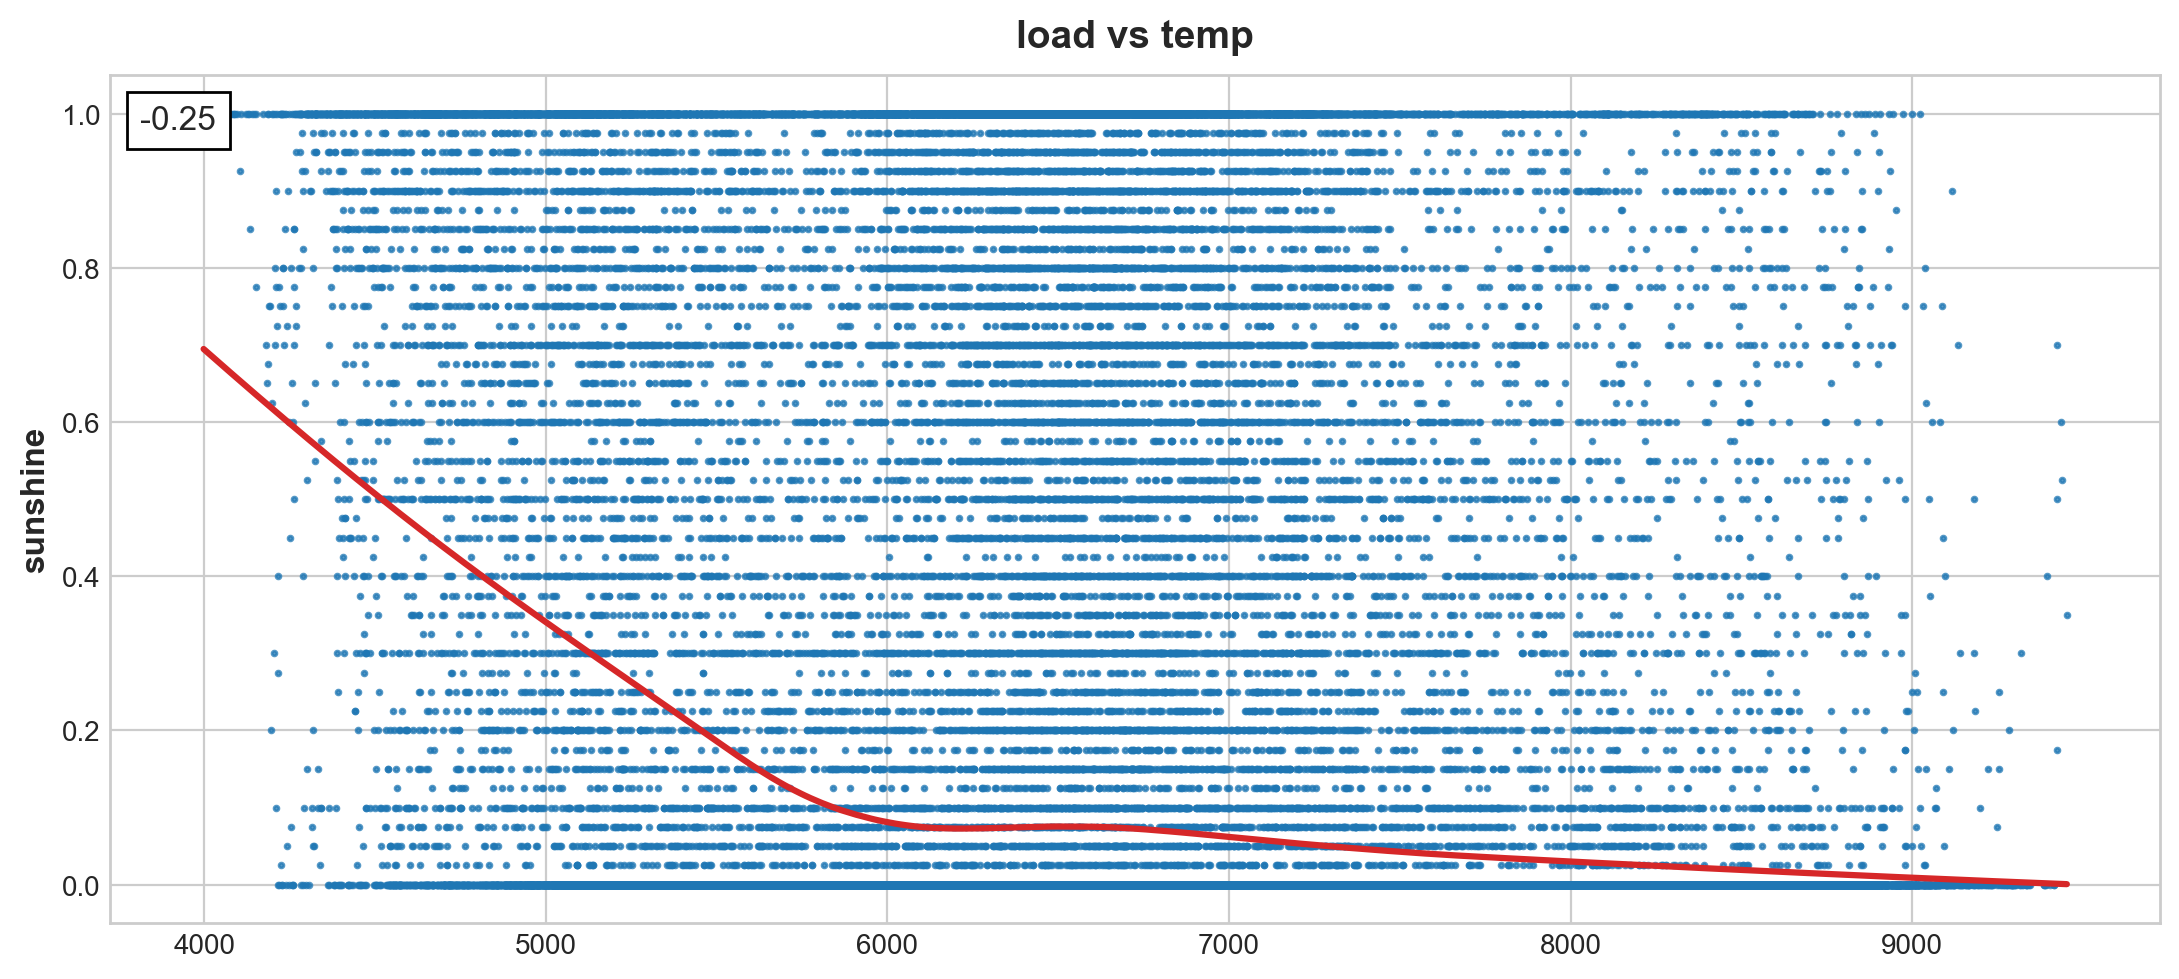

In [80]:
from matplotlib.offsetbox import AnchoredText
x_ = deseasonalized
y_ = weather_15['sunshine']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title='load vs sun', xlabel=x_.name, ylabel=y_.name)

In [ ]:
from matplotlib.offsetbox import AnchoredText
x_ = deseasonalized
y_ = weather_15['sunshine']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title='load vs sun', xlabel=x_.name, ylabel=y_.name)

[Text(0.5, 1.0, 'load vs windspeed'),
 Text(0.5, 0, ''),
 Text(0, 0.5, 'windspee')]

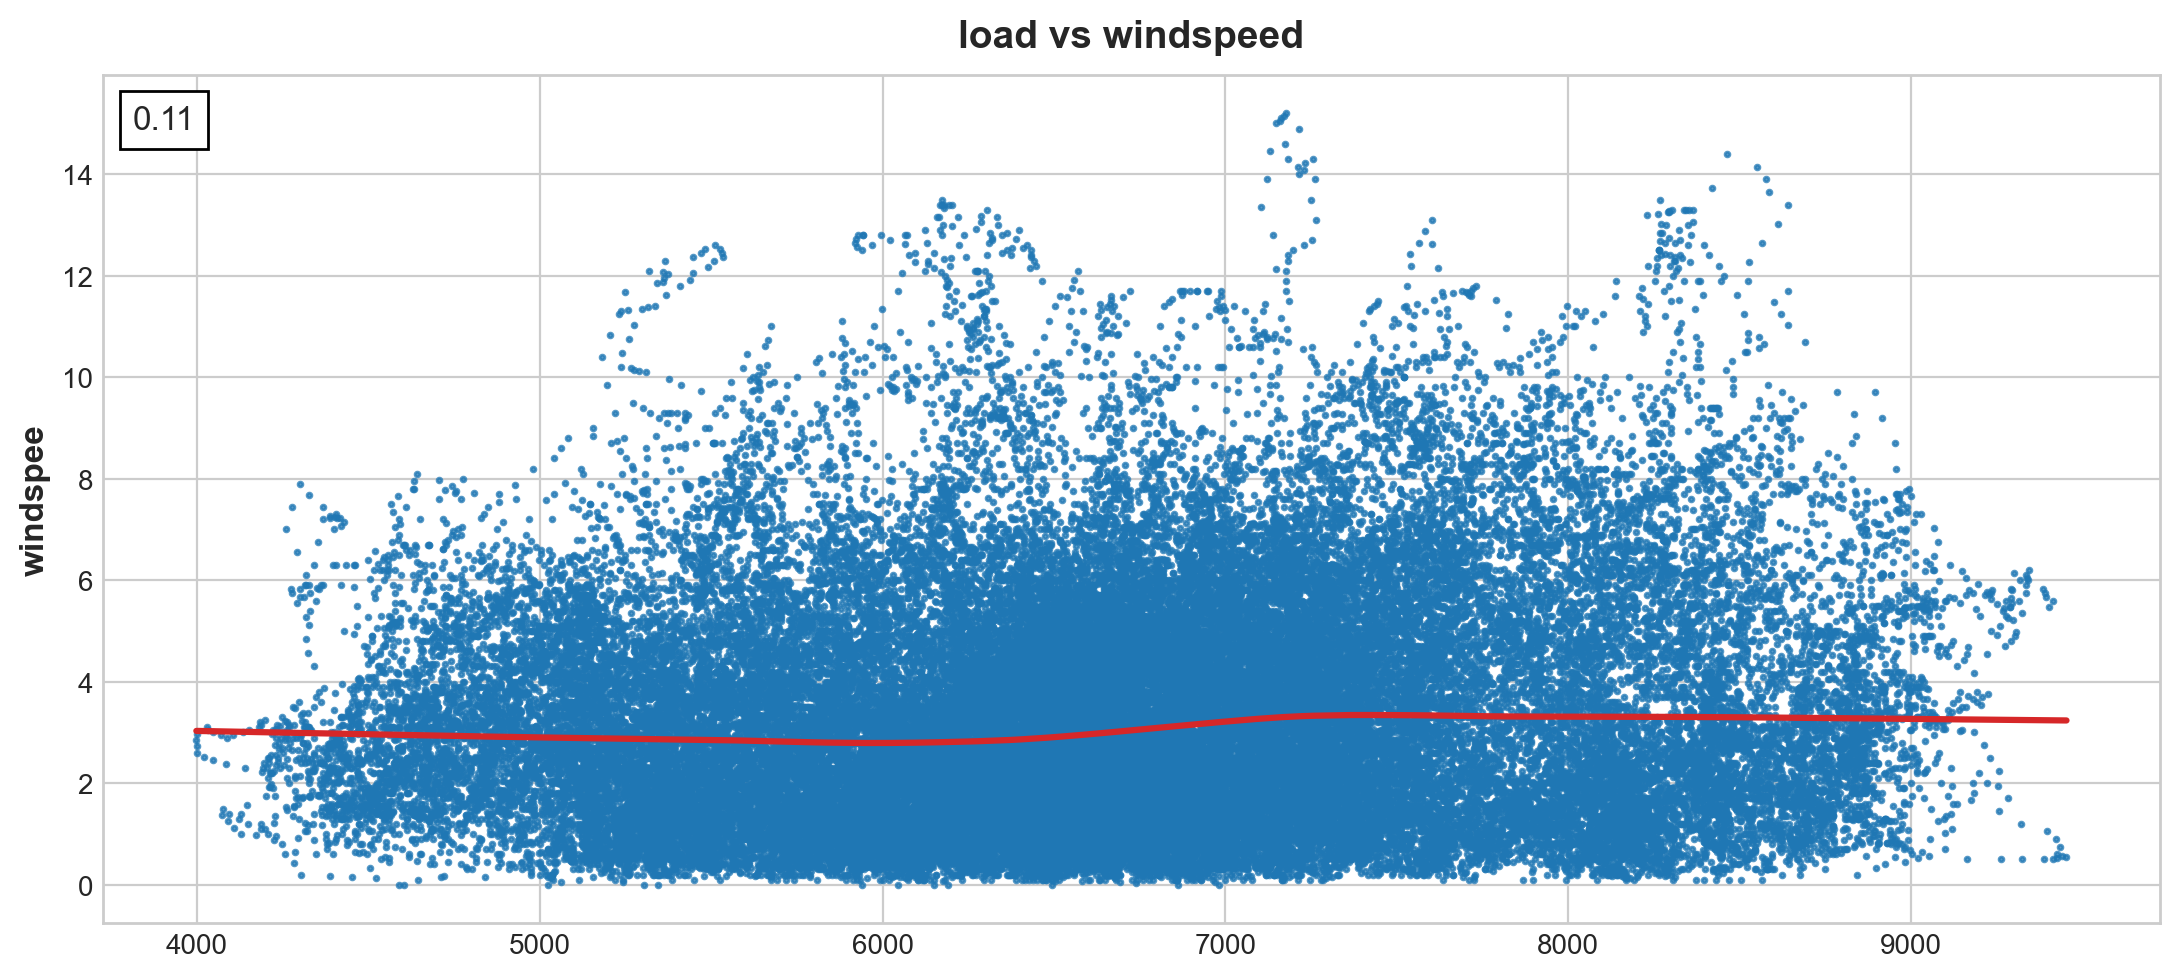

In [82]:
from matplotlib.offsetbox import AnchoredText
x_ = deseasonalized
y_ = weather_15['windspee']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title='load vs windspeed', xlabel=x_.name, ylabel=y_.name)


[Text(0.5, 1.0, 'load vs precipitation'),
 Text(0.5, 0, ''),
 Text(0, 0.5, 'precip')]

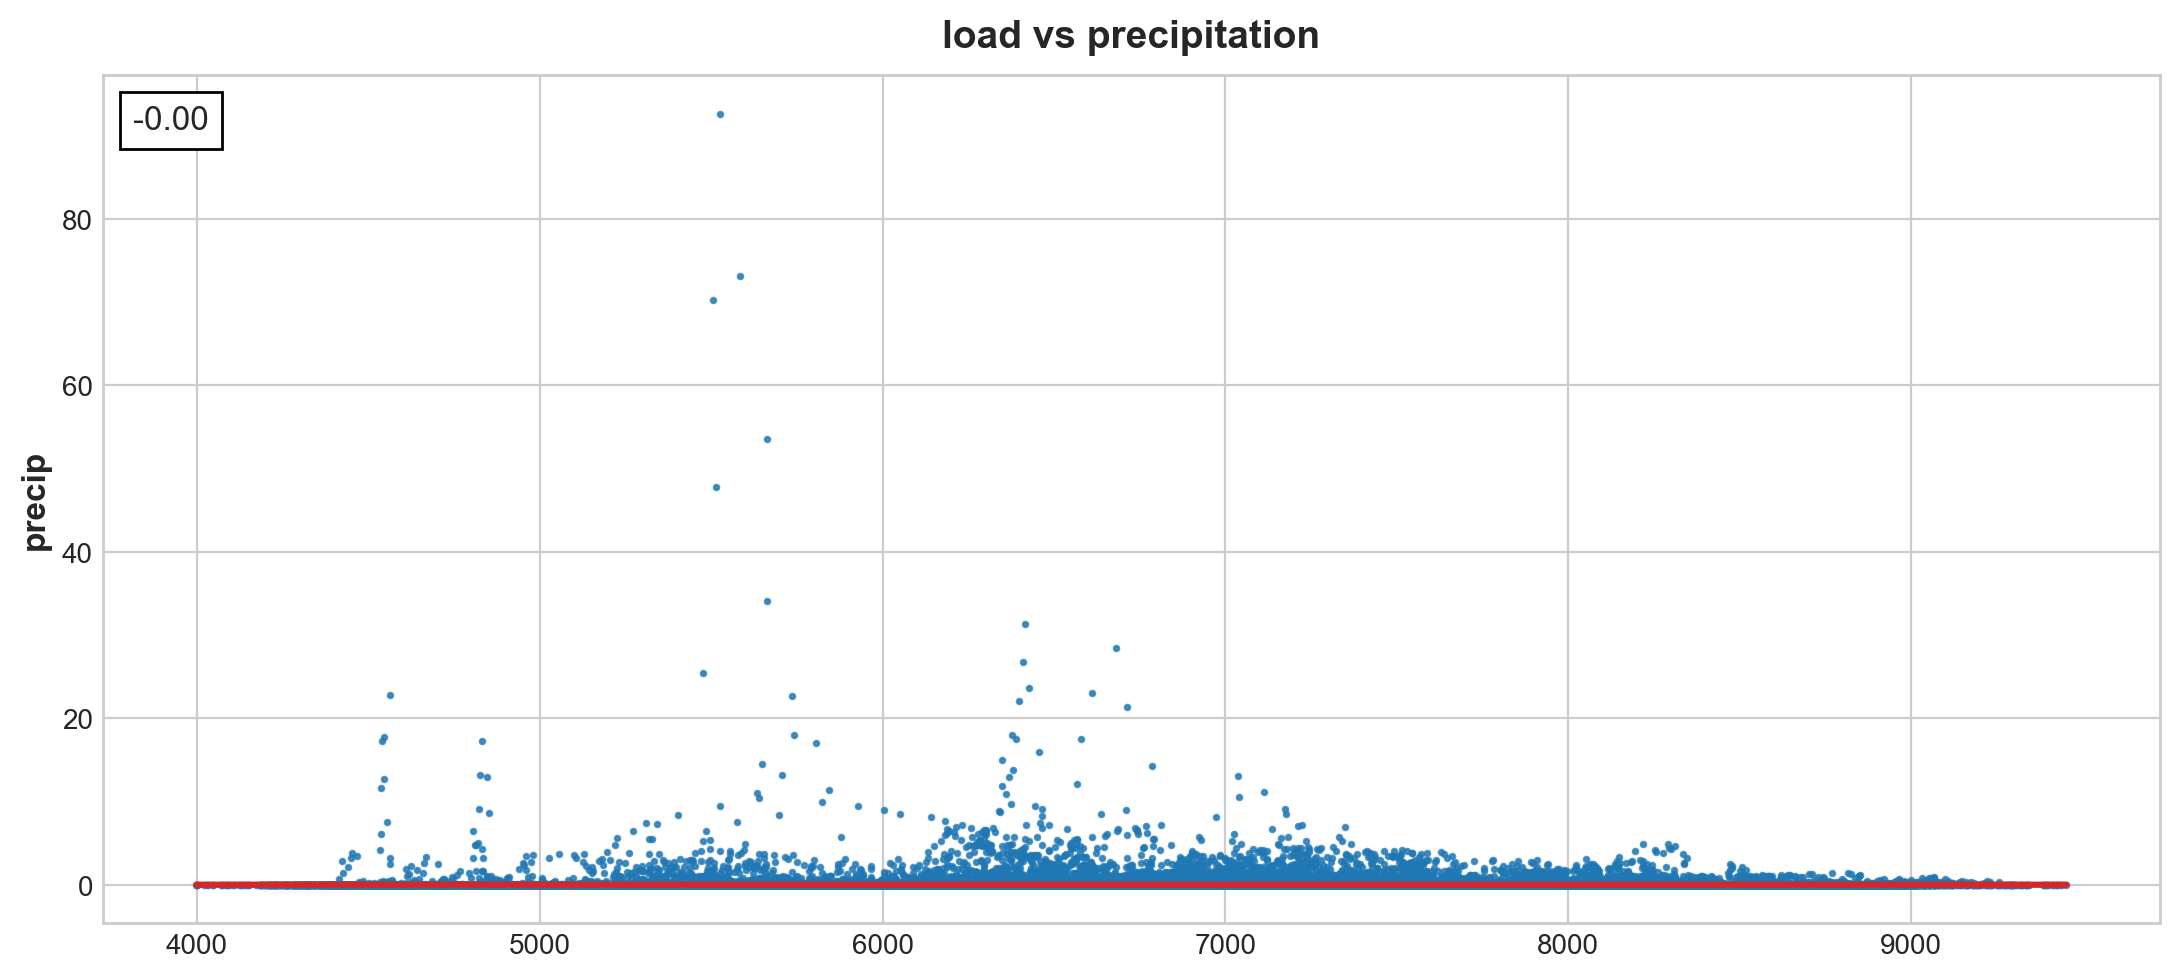

In [85]:
from matplotlib.offsetbox import AnchoredText
x_ = deseasonalized
y_ = weather_15['precip']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title='load vs precipitation', xlabel=x_.name, ylabel=y_.name)


In [28]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier

# Create Fourier terms matching your periodogram peaks
daily = CalendarFourier(freq='D', order=2)      # captures 24h, 12h, 8h cycles
weekly = CalendarFourier(freq='W', order=2)     # weekly + harmonic
annual = CalendarFourier(freq='A', order=6)     # annual + semiannual + quarterly + smaller peaks

dp = DeterministicProcess(
    index=data.index,
    constant=True,      # intercept
    order=1,            # linear trend
    seasonal=False,     # you already use Fourier → don't want dummy explosion
    additional_terms=[daily, weekly, annual],
    drop=True
)

X = dp.in_sample()


C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [27]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier

# Create Fourier terms matching your periodogram peaks
daily = CalendarFourier(freq='D', order=2)      # captures 24h, 12h, 8h cycles
weekly = CalendarFourier(freq='W', order=2)     # weekly + harmonic
annual = CalendarFourier(freq='A', order=6)     # annual + semiannual + quarterly + smaller peaks

dp = DeterministicProcess(
    index=data2.index,
    constant=True,      # intercept
    order=1,            # linear trend
    seasonal=False,     # you already use Fourier → don't want dummy explosion
    additional_terms=[daily, weekly, annual],
    drop=True
)

X_test = dp.in_sample()


C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [29]:
import pandas as pd
from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday, Easter

class AustriaHolidays(AbstractHolidayCalendar):
    rules = [
        Holiday("New Year", month=1, day=1),
        Holiday("Epiphany", month=1, day=6),
        Holiday("Easter Monday", month=1, day=1, offset=[Easter(), pd.DateOffset(days=1)]),
        Holiday("Labour Day", month=5, day=1),
        Holiday("Ascension Day", month=1, day=1, offset=[Easter(), pd.DateOffset(days=39)]),
        Holiday("Pentecost Monday", month=1, day=1, offset=[Easter(), pd.DateOffset(days=50)]),
        Holiday("Corpus Christi", month=1, day=1, offset=[Easter(), pd.DateOffset(days=60)]),
        Holiday("Assumption Day", month=8, day=15),
        Holiday("National Day", month=10, day=26),
        Holiday("All Saints Day", month=11, day=1),
        Holiday("Immaculate Conception", month=12, day=8),
        Holiday("Christmas Day", month=12, day=25),
        Holiday("St Stephen's Day", month=12, day=26),
    ]

# Generate holidays for 2023–2024
holidays = AustriaHolidays().holidays(start="2023-01-01", end="2024-12-31")

# Add to your dataframe
X["is_holiday"] = X.index.normalize().isin(holidays).astype(int)


In [30]:
holidays2 = AustriaHolidays().holidays(start="2025-01-01", end="2025-12-31")

# Add to your dataframe
X_test["is_holiday"] = X_test.index.normalize().isin(holidays).astype(int)

In [31]:
# Saturday = 5, Sunday = 6
X["weekend_flag"] = X.index.dayofweek.map({5: 1, 6: 2}).fillna(0).astype(int)

In [32]:
X_test["weekend_flag"] = X_test.index.dayofweek.map({5: 1, 6: 2}).fillna(0).astype(int)

In [111]:
print(X.index.duplicated().sum())

8


In [210]:
X = X[~X.index.duplicated(keep='first')]
X_test = X_test[~X_test.index.duplicated(keep='first')]
weather_15 = weather_15[~weather_15.index.duplicated(keep='first')]

In [264]:
print(X_test.index.duplicated().sum())

0


In [359]:
weather_15

,temp,precip,sunshine,windspee
time,,,,
2023-01-01 00:00:00,4.800,0.0,0.0,2.200
2023-01-01 00:15:00,4.875,0.0,0.0,2.275
2023-01-01 00:30:00,4.950,0.0,0.0,2.350
2023-01-01 00:45:00,5.025,0.0,0.0,2.425
2023-01-01 01:00:00,5.100,0.0,0.0,2.500
...,...,...,...,...
2024-12-30 22:45:00,-3.225,0.0,0.0,0.450
2024-12-30 23:00:00,-3.200,0.0,0.0,0.400
2024-12-30 23:15:00,-3.150,0.0,0.0,0.375


In [33]:
# Align X to weather_15 timestamps
common_index = X.index.intersection(weather_15.index)

X = X.loc[common_index]
weather_aligned = weather_15.loc[common_index]

X["temp"] = weather_aligned["temp"]
#X["precip"] = weather_aligned["precip"]
#X["sunshine"] = weather_aligned["sunshine"]
#X["windspeed"] = weather_aligned["windspee"]

In [34]:
# Align X to weather_15 timestamps
common_index2 = X_test.index.intersection(weather2_15.index)

X_test = X_test.loc[common_index2]
weather2_aligned = weather2_15.loc[common_index2]

X_test["temp"] = weather2_aligned["temp"]
#X_test["precip"] = weather2_aligned["precip"]
#X_test["sunshine"] = weather2_aligned["sunshine"]
#X_test["windspeed"] = weather2_aligned["windspeed"]


In [609]:
X.dropna(inplace = True)

In [610]:
X

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)",is_holiday,weekend_flag,temp,precip,sunshine
2023-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,-0.781831,0.623490,...,1.000000,0.000000,1.000000,0.000000,1.000000,1,2,4.800,0.0,0.0
2023-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,-0.775968,0.630773,...,1.000000,0.000897,1.000000,0.001076,0.999999,1,2,4.875,0.0,0.0
2023-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,-0.770036,0.638000,...,0.999999,0.001793,0.999998,0.002152,0.999998,1,2,4.950,0.0,0.0
2023-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,-0.764037,0.645172,...,0.999998,0.002690,0.999996,0.003228,0.999995,1,2,5.025,0.0,0.0
2023-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,-0.757972,0.652287,...,0.999996,0.003586,0.999994,0.004304,0.999991,1,2,5.100,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 22:45:00,1.0,70076.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.751840,0.659346,...,0.997391,-0.090184,0.995925,-0.108156,0.994134,0,0,-3.225,0.0,0.0
2024-12-30 23:00:00,1.0,70077.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.757972,0.652287,...,0.997443,-0.089293,0.996005,-0.107089,0.994249,0,0,-3.200,0.0,0.0
2024-12-30 23:15:00,1.0,70078.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.764037,0.645172,...,0.997494,-0.088403,0.996085,-0.106022,0.994364,0,0,-3.150,0.0,0.0
2024-12-30 23:30:00,1.0,70079.0,-0.130526,0.991445,-0.258819,0.965926,-0.382683,0.923880,0.770036,0.638000,...,0.997544,-0.087512,0.996163,-0.104955,0.994477,0,0,-3.100,0.0,0.0


In [35]:
y=data['Actual Total Load (MW)']

In [36]:
common_index = y.index.intersection(X.index)

y = y.loc[common_index]


In [37]:
y_test=data2['Actual Total Load (MW)']

In [38]:
common_index2 = y_test.index.intersection(X_test.index)

y_test = y_test.loc[common_index2]

In [39]:
y_test = y_test.astype(float)

In [238]:
y_test

2025-01-01 00:00:00    6475.6
2025-01-01 00:15:00    6438.0
2025-01-01 00:30:00    6407.6
2025-01-01 00:45:00    6357.6
2025-01-01 01:00:00    6325.6
                        ...  
2025-05-31 22:45:00    5250.4
2025-05-31 23:00:00    5142.0
2025-05-31 23:15:00    4997.6
2025-05-31 23:30:00    4939.2
2025-05-31 23:45:00    4844.4
Name: Actual Total Load (MW), Length: 14492, dtype: float64

In [689]:
dataset = y.values

In [690]:
training_data_len = int(np.ceil(len(dataset)*0.95))

In [691]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

In [692]:
training_data = scaled_data[:training_data_len]

In [693]:
X_train, y_train = [], []

In [694]:
for i in range(24*4*7, len(training_data)):
    X_train.append(training_data[i-24*4*7:i,0])
    y_train.append(training_data[i,0])

In [695]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [696]:
X_train = np.reshape(X_train, [X_train.shape[0], X_train.shape[1], 1])

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(64, return_sequences = True, input_shape = (X_train.shape[1],1)))
model.add(keras.layers.LSTM(64, return_sequences = False))
model.add(keras.layers.Dense(128, activation = 'relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary()
model.compile(optimizer = 'adam', loss = 'mae', metrics = [keras.metrics.RootMeanSquaredError()])
training = model.fit(X_train, y_train, epochs=20, batch_size=48)
test_data = scaled_data[training_data_len - 24*4*7]
X_test, y_test = [], dataset[training_data_len:]
for i in range(24*4*7, len(test_data)):
    X_test.append(test_data[i-24*4*7:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test[0], X_test[1],1))
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)

In [44]:
def make_lags(ts, lagfirst, laglast):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lagfirst, laglast + 1)
        },
        axis=1)

In [225]:
X_train = X.iloc[:-96*30*9]
X_test = X.iloc[-96*30*9:]
y_train = y.iloc[:-96*30*9]
y_test = y.iloc[-96*30*9:]

In [226]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.974928,-0.222521,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.972805,-0.231627,...,0.000358,1.000000,0.000536,1.000000,0.000715,1.000000,0.000894,1.000000,0.001073,0.999999
2020-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,0.970597,-0.240712,...,0.000715,1.000000,0.001073,0.999999,0.001431,0.999999,0.001788,0.999998,0.002146,0.999998
2020-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,0.968304,-0.249776,...,0.001073,0.999999,0.001609,0.999999,0.002146,0.999998,0.002682,0.999996,0.003219,0.999995
2020-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,0.965926,-0.258819,...,0.001431,0.999999,0.002146,0.999998,0.002861,0.999996,0.003576,0.999994,0.004292,0.999991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-04 23:45:00,1.0,149468.0,-0.065403,0.997859,-0.130526,0.991445,-0.195090,0.980785,-0.787627,0.616153,...,-0.912700,-0.408631,0.153360,0.988170,0.745914,-0.666042,-0.964571,-0.263825,0.303093,0.952961
2024-06-04 00:00:00,1.0,149469.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.781831,0.623490,...,-0.819972,0.572404,0.991723,-0.128398,-0.938710,-0.344707,0.672949,0.739689,-0.254671,-0.967028
2024-06-04 00:15:00,1.0,149470.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.787627,0.616153,...,-0.819767,0.572697,0.991654,-0.128930,-0.938957,-0.344036,0.673610,0.739087,-0.255709,-0.966754


In [228]:
idx_train, idx_test = train_test_split(
    data.index, test_size=0.05, shuffle=False,
)

X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

In [230]:
X_test

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-10 16:30:00,1.0,166623.0,-0.923880,-0.382683,0.707107,-0.707107,0.382683,0.923880,0.666347,-0.745642,...,0.326515,0.945192,0.478478,0.878099,0.617238,0.786776,0.738966,0.673742,0.840303,0.542117
2024-01-10 16:45:00,1.0,166624.0,-0.946930,-0.321439,0.608761,-0.793353,0.555570,0.831470,0.659346,-0.751840,...,0.326853,0.945075,0.478949,0.877843,0.617801,0.786334,0.739569,0.673081,0.840884,0.541215
2024-01-10 17:00:00,1.0,166625.0,-0.965926,-0.258819,0.500000,-0.866025,0.707107,0.707107,0.652287,-0.757972,...,0.327191,0.944958,0.479420,0.877585,0.618363,0.785892,0.740170,0.672420,0.841464,0.540313
2024-01-10 17:15:00,1.0,166626.0,-0.980785,-0.195090,0.382683,-0.923880,0.831470,0.555570,0.645172,-0.764037,...,0.327529,0.944841,0.479891,0.877328,0.618925,0.785450,0.740771,0.671758,0.842044,0.539409
2024-01-10 17:30:00,1.0,166627.0,-0.991445,-0.130526,0.258819,-0.965926,0.923880,0.382683,0.638000,-0.770036,...,0.327867,0.944724,0.480362,0.877071,0.619487,0.785007,0.741371,0.671095,0.842622,0.538506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,1.0,175388.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.984262,-0.176717,...,-0.001788,0.999998,-0.002682,0.999996,-0.003576,0.999994,-0.004471,0.999990,-0.005365,0.999986
2024-12-31 23:00:00,1.0,175389.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.982566,-0.185912,...,-0.001431,0.999999,-0.002146,0.999998,-0.002861,0.999996,-0.003576,0.999994,-0.004292,0.999991
2024-12-31 23:15:00,1.0,175390.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.980785,-0.195090,...,-0.001073,0.999999,-0.001609,0.999999,-0.002146,0.999998,-0.002682,0.999996,-0.003219,0.999995


In [686]:
import statsmodels.api as sm



model = sm.tsa.statespace.SARIMAX(
    y,
    exog=X,
    order=(2,1,1),
#    seasonal_order=(1,1,1,96),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
print(result.summary())


C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Actual Total Load (MW)   No. Observations:                70080
Model:                   SARIMAX(2, 1, 1)   Log Likelihood             -388260.152
Date:                    Sat, 06 Dec 2025   AIC                         776542.305
Time:                            19:21:09   BIC                         776643.036
Sample:                                 0   HQIC                        776573.371
                                  - 70080                                         
Covariance Type:                      opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.345e-06   3.07e-06      0.438      0.661   -4.67e-06    7.36e-06
trend           -0.5963      1.068     -0.558      0.577      -2.690       1.497
is_holiday  

In [651]:
y_fit = result.fittedvalues  # in-sample predictions

In [657]:
n_forecast = len(y_test)

forecast = result.get_forecast(steps=n_forecast, exog=X_test)  # if exogenous vars
y_pred = forecast.predicted_mean
y_pred.index = y_test.index  # align index

C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [392]:
X1 = make_lags(y, 24*4+3, 24*4+8).fillna(0.0)
X2 = make_lags(y, 48*4+1, 48*4+8).fillna(0.0)
X3 = make_lags(y, 72*4+1, 72*4+8).fillna(0.0)

In [393]:
Y = make_lags(y, -24*4+1, 0).fillna(0.0)

In [394]:
x1 = make_lags(y_test, 24*4+3, 24*4+8).fillna(0.0)
x2 = make_lags(y_test, 48*4+1, 48*4+8).fillna(0.0)
x3 = make_lags(y_test, 72*4+1, 72*4+8).fillna(0.0)

In [395]:
X = pd.concat([X,X1,X2,X3], axis = 1).fillna(0.0)
X_test = pd.concat([X_test,x1,x2,x3], axis = 1).fillna(0.0)
#y = Y.fillna(0.0)

In [396]:
X = X.astype(float)

In [397]:
X_test = X_test.astype(float)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
model = XGBRegressor()
_ = model.fit(X, y)

y_fit = pd.Series(model.predict(X), index=X.index)
y_pred = pd.Series(model.predict(X_test), index=X_test.index)



In [422]:
y_fit.dtype

dtype('float32')

In [423]:
y_pred.dtype

dtype('float32')

In [ ]:
# 1. select first row of every day (every 96 steps)
y_fit_daily = y_fit.iloc[::96]
y_pred_daily = y_pred.iloc[::96]

# 2. create time offsets for each 96-step 15-minute forecast
freq = '15T'
horizon = y_fit.shape[1]
offsets = pd.timedelta_range(start='0T', periods=horizon, freq=freq)

# 3. convert rows into a timestamp-indexed Series
def expand_forecast(df):
    series_list = []
    for ts, row in df.iterrows():
        idx = ts + offsets
        s = pd.Series(row.values, index=idx)
        series_list.append(s)
    return pd.concat(series_list)

# 4. expanded series
y_fit = expand_forecast(y_fit_daily)
y_pred = expand_forecast(y_pred_daily)


In [127]:
y_test, y_pred = y_test.align(y_pred, join='inner', axis = 0)

In [ ]:
y, y_fit = y.align(y_fit, join='inner', axis = 0)

C:\Users\as comp\AppData\Local\Temp\ipykernel_13728\2553292015.py:4: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  axs = y_pred.iloc[-96:].plot(color='C3', subplots=True, sharex=True, ax=axs)


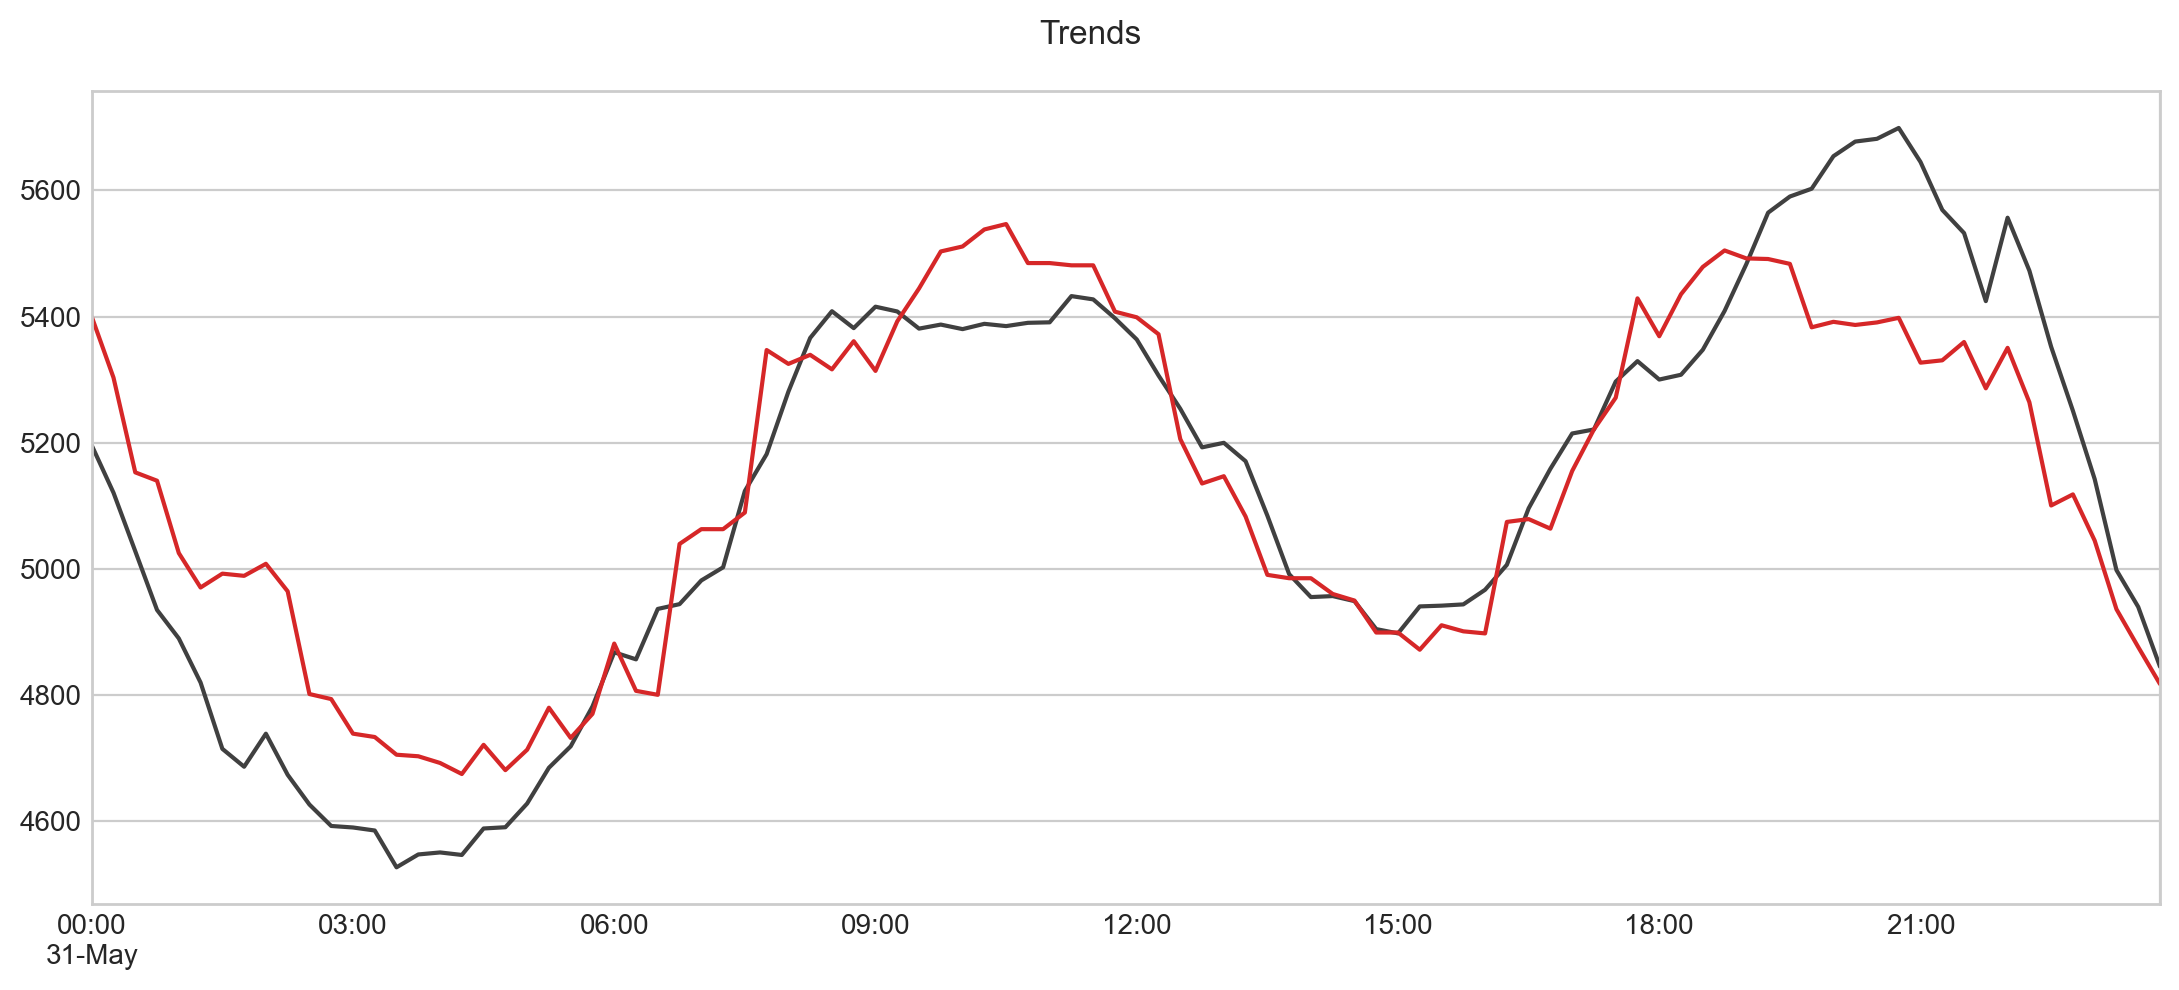

In [64]:
#axs = y.plot(color='0.25', subplots=True, sharex=True)
axs = y_test.iloc[-96:].plot(color='0.25', subplots=True, sharex=True)
#axs = y_fit.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_pred.iloc[-96:].plot(color='C3', subplots=True, sharex=True, ax=axs)
for ax in axs: ax.legend([])
_ = plt.suptitle("Trends")

In [227]:
data3 = pd.read_csv("C:/Users/as comp/Downloads/SW.csv")

In [228]:
data3.index = data3['MTU (CET/CEST)'].astype(str).str.split(" - ").str[0]
data3.index.rename('datetime', inplace = True)
data3.drop(['Area'], axis=1, inplace = True)
data3.drop(['MTU (CET/CEST)'], axis = 1, inplace = True)

In [229]:
data3.index = data3.index.str.replace(r"\s*\(.*?\)", "", regex=True)

In [230]:
data3.index = pd.to_datetime(data3.index)

In [231]:
data3 = data3[data3.index.month<3]

In [232]:
DATA = pd.concat([y_pred, data3['Day-ahead (MW)']], axis=1)
DATA.columns = ['load_actual', 'sw']

In [234]:
X = X.astype(float)

In [235]:
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5664 entries, 2025-01-01 00:00:00 to 2025-02-12 23:45:00
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   load_actual  5664 non-null   float64
 1   sw           5664 non-null   float64
dtypes: float64(2)
memory usage: 132.8 KB


In [242]:
import pandas as pd
import numpy as np

def smooth_between_zero_crossings(X, Pmax=1500, Emax=10000, dt=0.25, tol=20.0, max_iter=60):
    """
    Returns X with added columns:
      - pflow : raw flow = sw - load_actual
      - base  : found daily base (constant for smoothing interval)
      - SS    : smoothed storage flow = pflow + base (constrained later to [-Pmax, Pmax])
      - SoC   : battery state (kWh), continuous across days, clipped to [0, Emax]
      - peak_curve : load_actual - base
    Notes:
      - dt: hours per timestep (default 1.0). Adjust if your index timestep differs.
      - tol: acceptable energy mismatch (kWh) between available and required for that day.
    """
    X = X.copy()

    # Basic checks
    if not isinstance(X.index, pd.DatetimeIndex):
        raise ValueError("X must have DatetimeIndex")
    if "sw" not in X.columns or "load_actual" not in X.columns:
        raise ValueError("X must contain sw and load_actual")

    # raw flow (power)
    X['pflow'] = X['sw'] - X['load_actual']

    # prepare result columns
    X['base'] = np.nan
    X['SS'] = np.nan
    X['SoC'] = np.nan
    X['peak_curve'] = np.nan

    E = 0.0  # continuous SoC (kWh)
    # iterate day by day using groupby on date
    for day, grp in X.groupby(X.index.date):
        # use grp (subset) for per-day calculations
        idx = grp.index

        # compute daily mn/mx and initial base
        mn = float(grp['load_actual'].min())
        mx = float(grp['load_actual'].max())
        # handle flat-day
        if mx == mn:
            # no crossing possible, choose trivial base = mn
            base = mn
            zh1 = idx[0]
            zh2 = idx[-1]
        else:
            base = 0.5 * (mn + mx)
            # e.g. 5% of daily range
            
            # helper to find zh1, zh2 given a base
            def find_zhs(base_val):
                zc = grp['pflow'] + base_val
                # sign change detection: zc * zc.shift(1) < 0
                sc = (zc * zc.shift(1)) < 0
                zero_hours = grp.index[sc.fillna(False)]
                zh1 = zh2 = None
                if len(zero_hours) > 0:
                    morning = [t for t in zero_hours if t.hour < 12]
                    afternoon = [t for t in zero_hours if t.hour >= 12]
                    if morning:
                        zh1 = pd.Timestamp(morning[0])
                    if afternoon:
                        zh2 = pd.Timestamp(afternoon[-1])
                    # fallback if we only got one crossing
                    if zh1 is None or zh2 is None:
                        if len(zero_hours) > 2:
                            zh1, zh2 = pd.Timestamp(zero_hours[0]), pd.Timestamp(zero_hours[-1])
                        elif zh1 is None:
                            zh1 = idx[0]
                        else:
                            zh2 = idx[-1]
                else:
                    zh1 = idx[0]
                    zh2 = idx[-1]
                return zh1, zh2

            # bisection search for base so that available_energy - required_energy in [0, tol]
            lo, hi = mn, mx
            zh1, zh2 = find_zhs(base)
            # compute ED and available helper
            def compute_ED_and_available(base_val):
                zh1_loc, zh2_loc = find_zhs(base_val)
                mask = (grp.index >= zh1_loc) & (grp.index <= zh2_loc)
                # raw_interval: pflow + base (unit: kW). Energy over timestep = * dt
                raw_interval = (grp.loc[mask, 'pflow'] + base_val)  # kW
                ED = (-raw_interval.clip(upper=0)).sum() * dt      # kWh required (deficit)
                # compute available before zh1: cumulative sum from start to zh1-1
                # cumulative energy from day's start until just before zh1
                before_mask = grp.index < zh1_loc
                if before_mask.any():
                    energy_before = (grp.loc[before_mask, 'pflow'] + base_val).cumsum().iloc[-1] * dt
                else:
                    energy_before = 0.0
                total_available = min(Emax, max(0.0, E + energy_before))  # E is SoC entering the day
                return ED, total_available, zh1_loc, zh2_loc

            ED, total_available, zh1, zh2 = compute_ED_and_available(base)

            lo = mn
            hi = mx
            
            it = 0
            fell_to_min = False
            
            while it < max_iter:
                diff = total_available - ED
            
                if 0 <= diff <= tol:
                    break
            
                # --- standard bisection update ---
                if diff < 0:
                    lo = base
                else:
                    hi = base
            
                base = 0.5 * (lo + hi)
            
                # --- detect collapse toward minimum ---
                if abs(base - mn) < 1e-2:          # converged to min
                    fell_to_min = True
                    break
            
                # recompute energy quantities
                ED, total_available, zh1, zh2 = compute_ED_and_available(base)
                it += 1
            
            
            # ------------------------------------------------------------------
            #     FALLBACK CASE: base converged to mn → rescue by flipping range
            # ------------------------------------------------------------------
            if fell_to_min:
            
                # reverse and expand lower bound
                # new_hi = old mn
                # new_lo = mn - (mx - mn)  (push lower)
                new_hi = mn
                new_lo = mn - (mx - mn)
            
                # reset
                lo = new_lo
                hi = new_hi
                it = 0
            
                # restart bisection using extended interval
                while it < max_iter:
                    base = 0.5 * (lo + hi)
            
                    ED, total_available, zh1, zh2 = compute_ED_and_available(base)
                    diff = total_available - ED
            
                    if 0 <= diff <= tol:
                        break
            
                    if diff < 0:
                        lo = base
                    else:
                        hi = base
            
                    it += 1


            # done bisection for this day
        
        # now we have base, zh1, zh2
        # assign base for all timestamps of the day
        X.loc[idx, 'base'] = base

        # compute SS for the day (power), then limit by Pmax
        SS_day = (grp['pflow'] + base)
        X.loc[idx, 'SS'] = SS_day.values
        X.loc[idx, 'peak_curve'] = (grp['load_actual'] - base).values

        # integrate SoC sample-by-sample to maintain per-step clipping
        for t in idx:
            flow = float(X.loc[t, 'SS'])  # kW
            E = E + flow * dt             # kWh
            E = max(0.0, min(E, Emax))
            X.loc[t, 'SoC'] = E

    return X


In [243]:
X2 = smooth_between_zero_crossings(X)

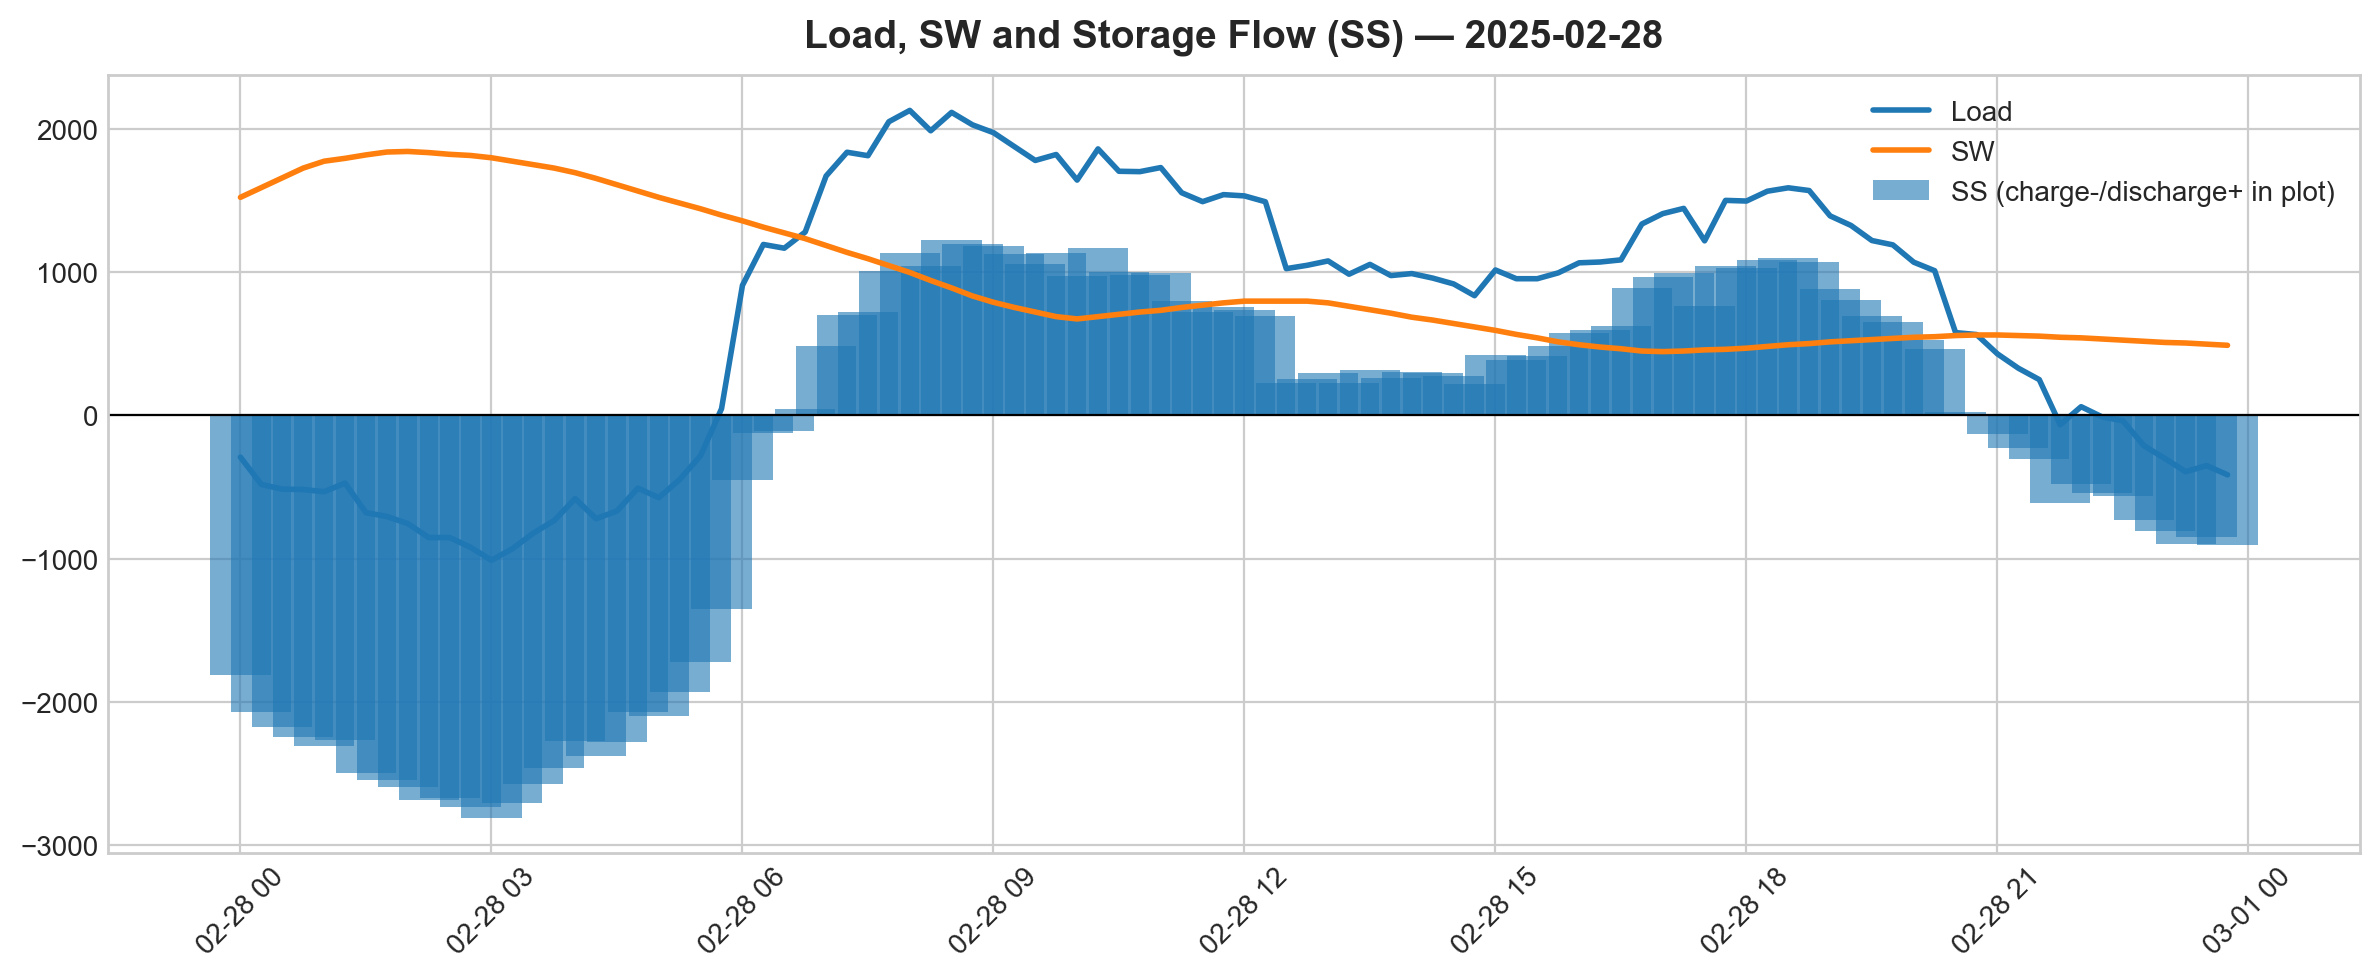

In [259]:
#X2['SoC'] = X2.SS.cumsum()
day_str = "2025-02-28"
day = X2.loc[day_str]
#print(day.loc[[1], 'base'])
#print(day["SS_raw"].max())
#print(day["SS_raw"].min())
plt.figure(figsize=(12,5))

# Line plots for load and SW
plt.plot(day.index, day.peak_curve, label="Load", linewidth=2)
plt.plot(day.index, day.sw, label="SW", linewidth=2)
#plt.plot(day.index, day.sw, label="SoC", linewidth=2)

# SS bar plot with sign flipped:
# Original SS > 0 = charging → plot as negative
# Original SS < 0 = discharging → plot as positive
SS_plot = -day.SS

plt.bar(day.index, SS_plot, width=0.03, alpha=0.6, label="SS (charge-/discharge+ in plot)")
plt.bar(day.index, day.SoC, width=0.03, alpha=0.3, label="Stored Energy")

#battery_plot = -day.battery_energy

#plt.bar(day.index, battery_plot, width=0.03, alpha=0.6, label="battery_energy")
plt.axhline(0, color="k", linewidth=0.8)
plt.legend()
plt.title(f"Load, SW and Storage Flow (SS) — {day_str}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [261]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import date

# -------------------------------------------------------
# EXPECTED DATA YOU ALREADY HAVE
# -------------------------------------------------------
# y_pred        → predicted load (Series)
# y_test        → actual load (Series)
# X2            → output of smooth_between_zero_crossings()
# weather_15    → weather dataframe (temp, precip, sunshine)

# Make sure these exist when running the GUI
# (You will just import them at the top)
# from your_model_script import y_pred, y_test, X2, weather_15


# -------------------------------------------------------
# STREAMLIT PAGE CONFIG
# -------------------------------------------------------
st.set_page_config(
    page_title="Austria Load Forecast Dashboard",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.title("⚡ Austria Load Forecast Dashboard")
st.markdown("An interactive interface for **load forecasting, storage flow, and base load analysis**.")


# -------------------------------------------------------
# SIDEBAR: SELECT A DAY
# -------------------------------------------------------
all_days = sorted(list(set(y_pred.index.date)))
default_day = all_days[0]

selected_day = st.sidebar.date_input(
    "Select a day",
    value=default_day,
    min_value=min(all_days),
    max_value=max(all_days)
)

# convert to timestamp day
day_str = pd.to_datetime(selected_day).strftime("%Y-%m-%d")

# filter daily data
day_pred = y_pred.loc[day_str]
day_actual = y_test.loc[day_str]
day_X2 = X2.loc[day_str]
day_weather = weather2_15.loc[day_str]


# -------------------------------------------------------
# WEATHER PANEL (MOBILE-STYLE)
# -------------------------------------------------------
st.subheader("🌤️ Weather Panel")

col1, col2, col3, col4 = st.columns([1, 1, 1, 1])

with col1:
    st.metric("🌡 Temperature", f"{day_weather['temp'].mean():.1f} °C")

with col2:
    st.metric("🌧 Precipitation", f"{day_weather['precip'].sum():.1f} mm")

with col3:
    st.metric("☀ Sunshine", f"{day_weather['sunshine'].sum():.1f} min")

with col4:
    cond = "☀ Clear" if day_weather["sunshine"].mean() > 50 else "☁ Cloudy"
    st.metric("Condition", cond)


# -------------------------------------------------------
# PLOT 1: FORECASTED vs ACTUAL LOAD
# -------------------------------------------------------
st.subheader("📈 Forecasted vs Actual Load")

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=day_actual.index, y=day_actual, mode='lines', name='Actual Load', line=dict(width=2)
))
fig1.add_trace(go.Scatter(
    x=day_pred.index, y=day_pred, mode='lines', name='Forecasted Load', line=dict(width=2)
))
fig1.update_layout(height=350, xaxis_title="Time", yaxis_title="MW")
st.plotly_chart(fig1, use_container_width=True)


# -------------------------------------------------------
# PLOT 2: STORAGE FLOW + SOC
# -------------------------------------------------------
st.subheader("🔋 Storage Flow & SoC")

fig2 = go.Figure()

# Energy Flow (SS)
fig2.add_trace(go.Bar(
    x=day_X2.index,
    y=-day_X2['SS'],
    name="Storage Flow (charge−, discharge+)"
))

# SoC Line
fig2.add_trace(go.Scatter(
    x=day_X2.index,
    y=day_X2['SoC'],
    name="State of Charge (kWh)",
    yaxis="y2",
    line=dict(width=3)
))

fig2.update_layout(
    height=350,
    xaxis=dict(title="Time"),
    yaxis=dict(title="Flow (kW)"),
    yaxis2=dict(
        title="SoC (kWh)",
        overlaying='y',
        side='right'
    )
)

st.plotly_chart(fig2, use_container_width=True)


# -------------------------------------------------------
# PLOT 3: BASE LOAD CURVE
# -------------------------------------------------------
st.subheader("📉 Base Load of the Day")

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=day_X2.index,
    y=day_X2['base'],
    mode='lines',
    name="Base Load",
    line=dict(width=3, color="green")
))
fig3.update_layout(height=300, xaxis_title="Time", yaxis_title="Base Load (MW)")
st.plotly_chart(fig3, use_container_width=True)


# -------------------------------------------------------
# END
# -------------------------------------------------------
st.success("Dashboard updated! Select another day from the sidebar.")


2025-12-08 01:07:34.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:34.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-08 01:07:35.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [215]:
y_pred

datetime
2024-03-10 01:00:00    4790.554188
2024-03-10 01:15:00    4724.862690
2024-03-10 01:30:00    4666.034415
2024-03-10 01:45:00    4615.061198
2024-03-10 02:00:00    4572.949456
                          ...     
2024-12-31 22:45:00    6577.460918
2024-12-31 23:00:00    6485.556383
2024-12-31 23:15:00    6394.071763
2024-12-31 23:30:00    6303.473063
2024-12-31 23:45:00    6214.269181
Length: 8640, dtype: float64

In [218]:
X_test

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2024-02-12 00:00:00,1.0,172513.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.991723,0.128398,0.829677,-0.558244,0.254671,-0.967028,-0.447094,-0.894487,-0.926324,-0.376728
2024-02-12 00:15:00,1.0,172514.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.009350,0.999956,...,0.991769,0.128044,0.829377,-0.558689,0.253979,-0.967210,-0.447893,-0.894087,-0.926728,-0.375734
2024-02-12 00:30:00,1.0,172515.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,0.018699,0.999825,...,0.991814,0.127689,0.829078,-0.559134,0.253287,-0.967391,-0.448693,-0.893686,-0.927130,-0.374739
2024-02-12 00:45:00,1.0,172516.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,0.028046,0.999607,...,0.991860,0.127334,0.828777,-0.559578,0.252595,-0.967572,-0.449492,-0.893285,-0.927532,-0.373744
2024-02-12 01:00:00,1.0,172517.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,0.037391,0.999301,...,0.991905,0.126979,0.828477,-0.560023,0.251903,-0.967752,-0.450290,-0.892882,-0.927932,-0.372749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,1.0,175388.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.984262,-0.176717,...,-0.001788,0.999998,-0.002682,0.999996,-0.003576,0.999994,-0.004471,0.999990,-0.005365,0.999986
2024-12-31 23:00:00,1.0,175389.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.982566,-0.185912,...,-0.001431,0.999999,-0.002146,0.999998,-0.002861,0.999996,-0.003576,0.999994,-0.004292,0.999991
2024-12-31 23:15:00,1.0,175390.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.980785,-0.195090,...,-0.001073,0.999999,-0.001609,0.999999,-0.002146,0.999998,-0.002682,0.999996,-0.003219,0.999995


In [197]:
y_test

datetime
2024-03-10 01:00:00    5653.2
2024-03-10 01:15:00    5542.0
2024-03-10 01:30:00    5506.8
2024-03-10 01:45:00    5454.0
2024-03-10 02:00:00    5433.6
                        ...  
2024-12-31 22:45:00    6715.6
2024-12-31 23:00:00    6656.8
2024-12-31 23:15:00    6585.6
2024-12-31 23:30:00    6531.6
2024-12-31 23:45:00    6452.0
Name: Actual Total Load (MW), Length: 8640, dtype: float64

In [42]:
print("Mean Absolute Error: " + str(mean_absolute_error(y, y_fit)))

Mean Absolute Error: 83.80287113416139


In [61]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_test, y_pred)))

Mean Absolute Error: 330.7663257705221


In [76]:
print("Mean Absolute Error: " + str(mean_absolute_error(y, data['Day-ahead Total Load Forecast (MW)'])))

Mean Absolute Error: 289.52233812129504


In [66]:
y_deseasoned_fit = y - y_fit
y_deseasoned_pred = y_test - y_pred

NameError: name 'lag' is not defined

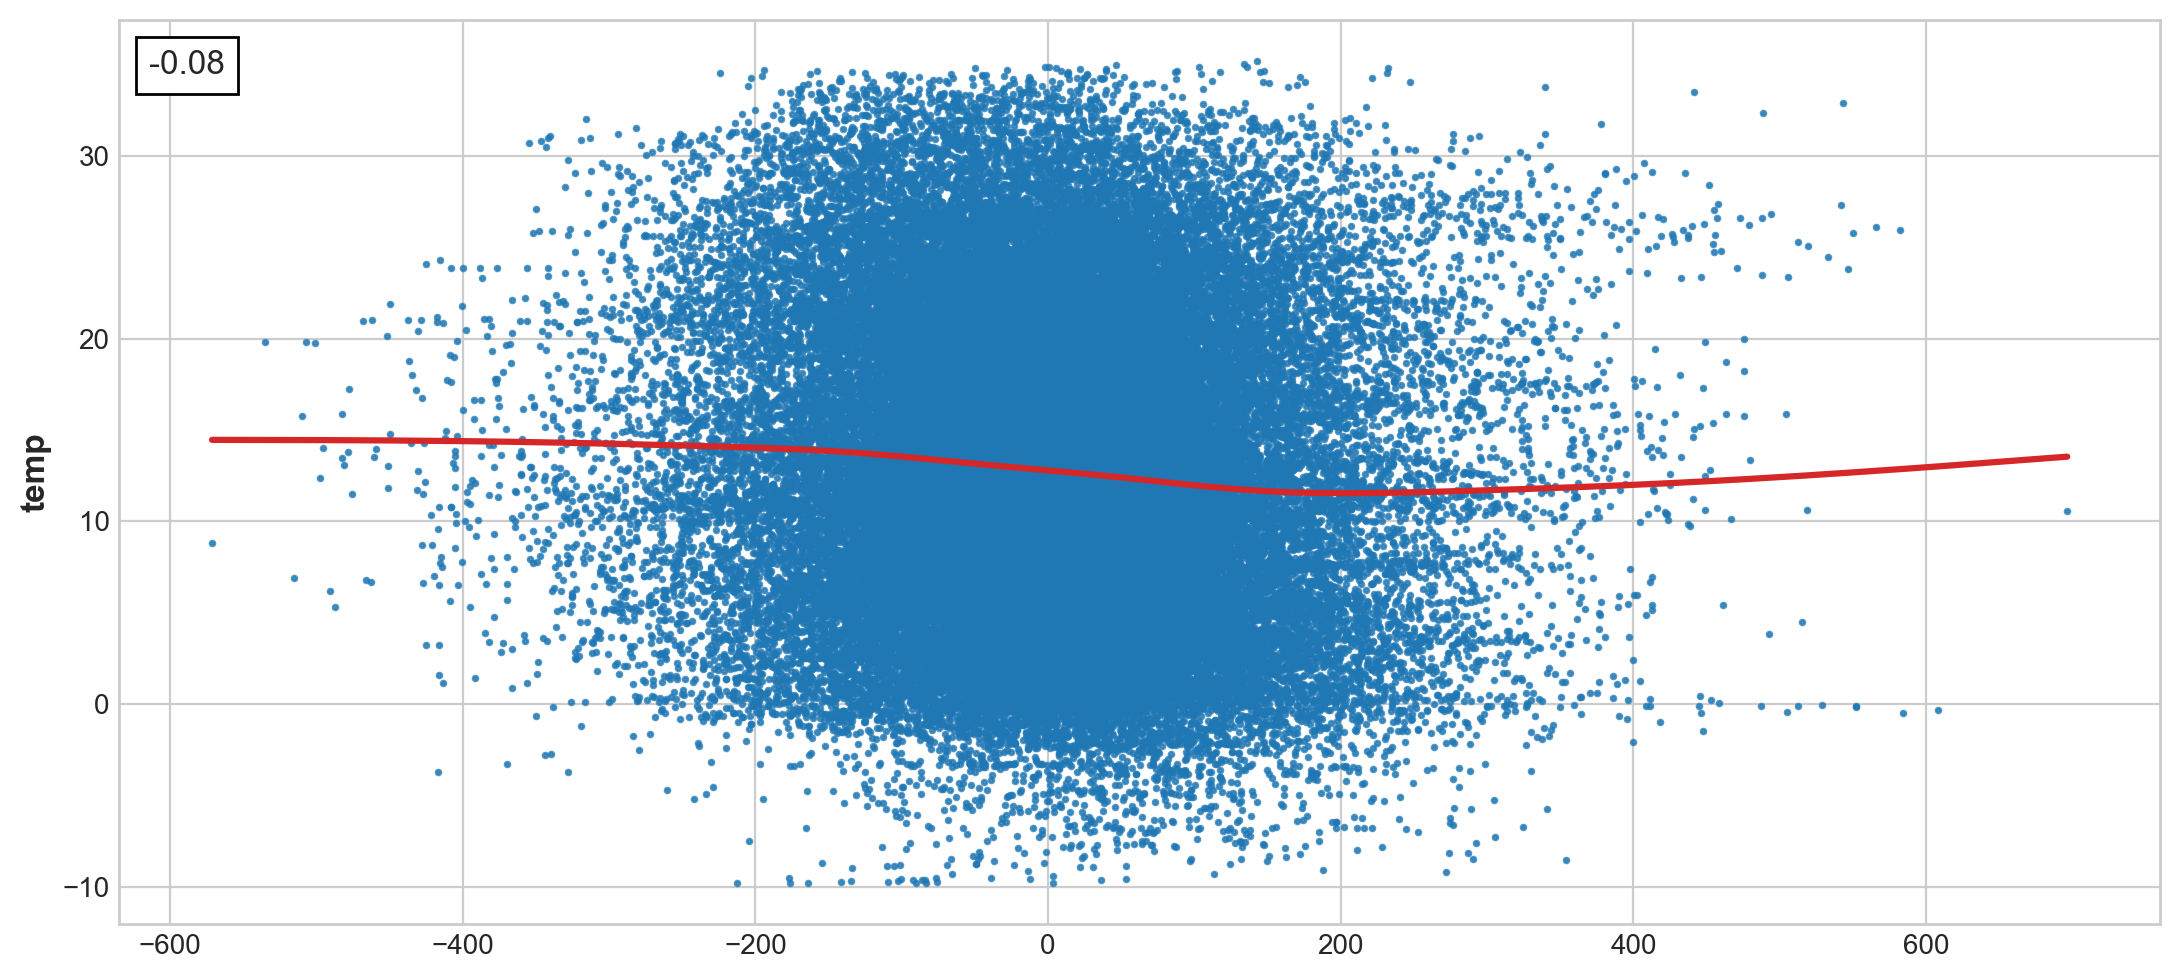

In [73]:
from matplotlib.offsetbox import AnchoredText
x_ = y_deseasoned_fit
y_ = weather_15['temp']
common_index = y_.index.intersection(x_.index)

x_ = x_.loc[common_index]
y_ = y_.loc[common_index]
x_, y_ = x_.align(y_, axis = 0)
corr = y_.corr(x_)
fig, ax = plt.subplots()
scatter_kws = dict(
    alpha=0.75,
    s=3,
)
line_kws = dict(color='C3', )
ax = sns.regplot(x=x_,
                 y=y_,
                 scatter_kws=scatter_kws,
                 line_kws=line_kws,
                 lowess=True,
                 ax=ax)
at = AnchoredText(
    f"{corr:.2f}",
    prop=dict(size="large"),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("square, pad=0.0")
ax.add_artist(at)
ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)

C:\Users\as comp\AppData\Local\Temp\ipykernel_11044\3016625488.py:5: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  axs = y_deseasoned_pred.plot(


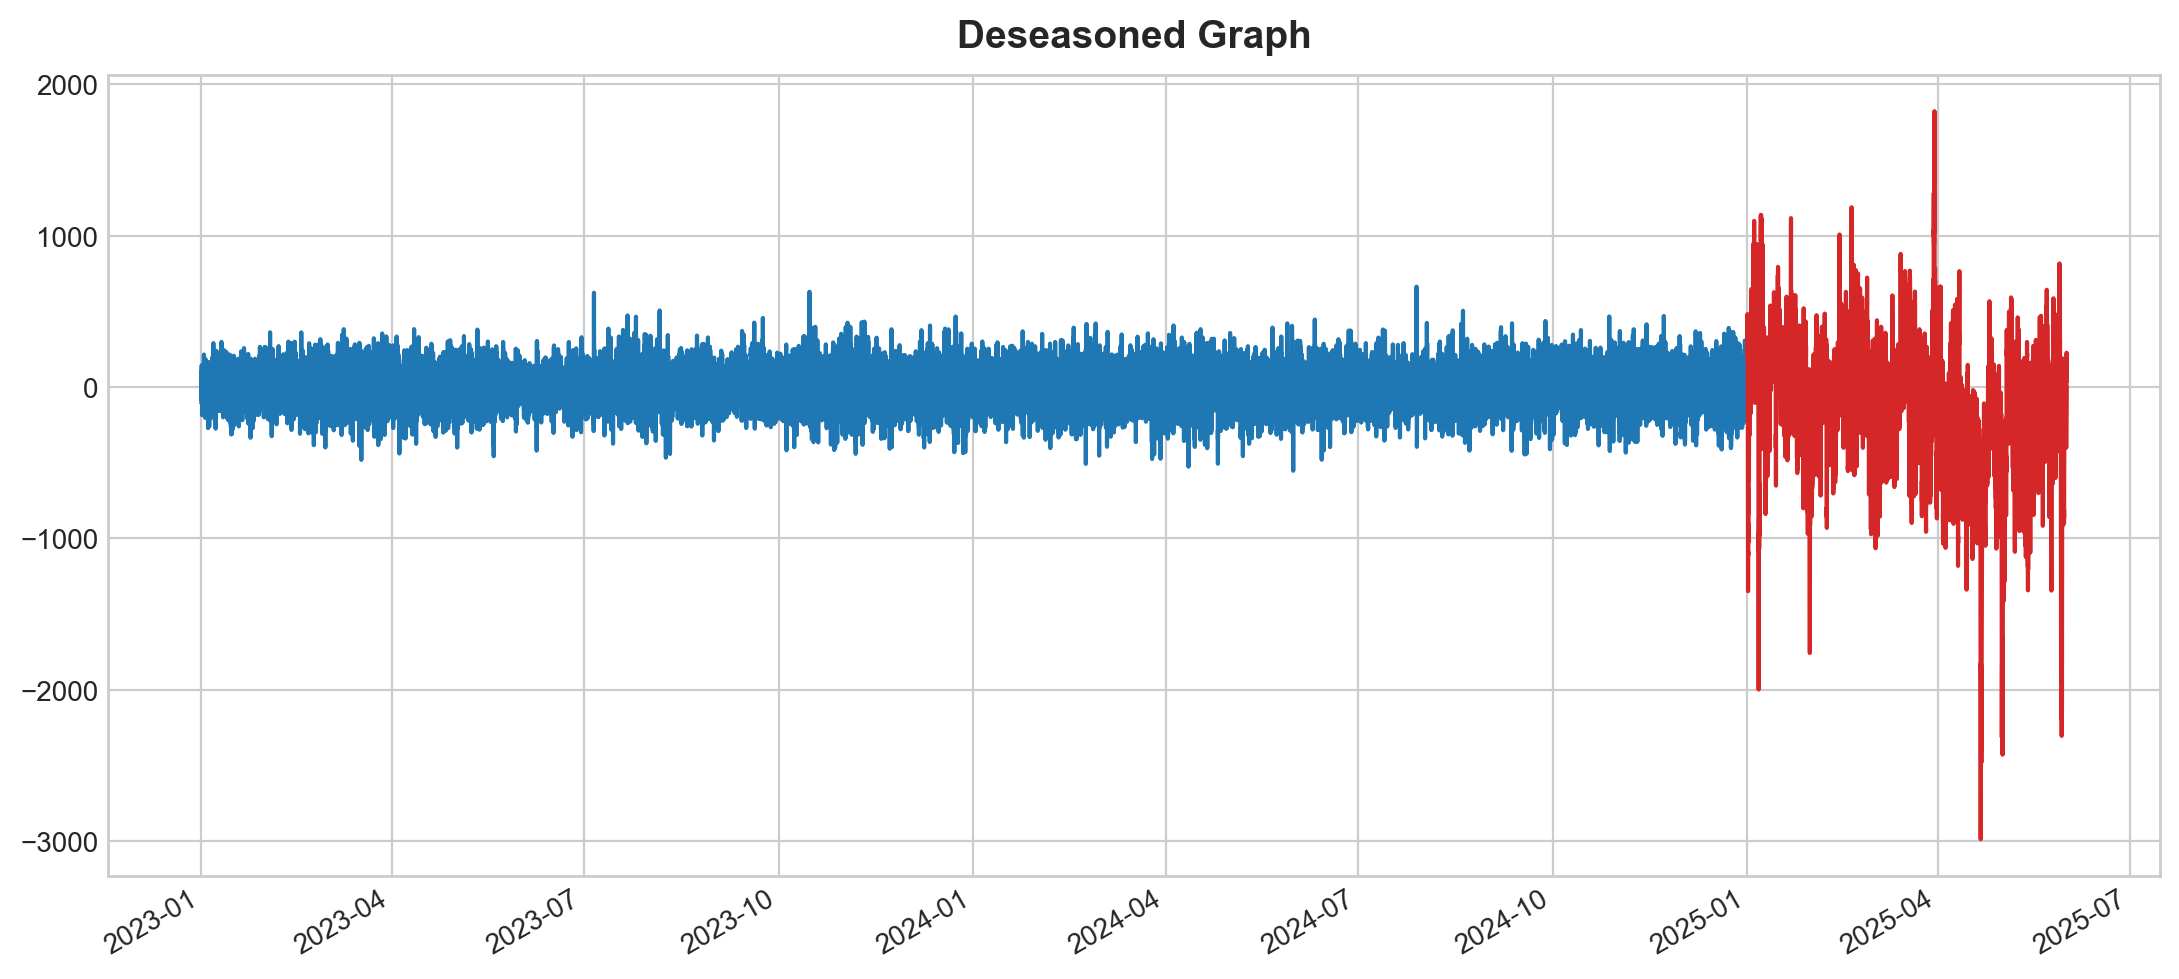

In [57]:
axs = y_deseasoned_fit.plot(
    color='C0', figsize=(11, 5), subplots=True, sharex=True,
    title=['Deseasoned Graph'],
)
axs = y_deseasoned_pred.plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

In [465]:
y_resid = y - y_fit

In [480]:
y_resid

2020-01-01 00:00:00    2697.823885
2020-01-01 00:15:00    2682.075111
2020-01-01 00:30:00    2660.672845
2020-01-01 00:45:00    2639.243066
2020-01-01 01:00:00    2685.550178
                          ...     
2024-01-01 13:00:00   -1398.744857
2024-01-01 13:15:00   -1478.924009
2024-01-01 13:30:00   -1519.446846
2024-01-01 13:45:00   -1576.560766
2024-01-01 14:00:00   -1598.935614
Length: 140377, dtype: float64

In [466]:
X = pd.DataFrame(index=X.index)
X_test = pd.DataFrame(index=X_test.index)

In [482]:
X_train

""
datetime
2020-01-01 00:00:00
2020-01-01 00:15:00
2020-01-01 00:30:00
2020-01-01 00:45:00
2020-01-01 01:00:00
...
2024-01-01 13:00:00
2024-01-01 13:15:00
2024-01-01 13:30:00


In [440]:
X_train

""


In [499]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier

# Create Fourier terms matching your periodogram peaks
daily = CalendarFourier(freq='D', order=3)      # captures 24h, 12h, 8h cycles
weekly = CalendarFourier(freq='W', order=2)     # weekly + harmonic
annual = CalendarFourier(freq='A', order=6)     # annual + semiannual + quarterly + smaller peaks

dp = DeterministicProcess(
    index=data.index,
    constant=True,      # intercept
    order=1,            # linear trend
    seasonal=False,     # you already use Fourier → don't want dummy explosion
    additional_terms=[daily, weekly, annual],
    drop=True
)

X = dp.in_sample()


In [500]:
idx_train, idx_test = train_test_split(
    data.index, test_size=0.2, shuffle=False,
)

X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
#y_train, y_test = y.loc[idx_train], y.loc[idx_test]

In [458]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000e+00,0.974928,-0.222521,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,9.807853e-01,0.972805,-0.231627,...,0.000358,1.000000,0.000536,1.000000,0.000715,1.000000,0.000894,1.000000,0.001073,0.999999
2020-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,9.238795e-01,0.970597,-0.240712,...,0.000715,1.000000,0.001073,0.999999,0.001431,0.999999,0.001788,0.999998,0.002146,0.999998
2020-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,8.314696e-01,0.968304,-0.249776,...,0.001073,0.999999,0.001609,0.999999,0.002146,0.999998,0.002682,0.999996,0.003219,0.999995
2020-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,7.071068e-01,0.965926,-0.258819,...,0.001431,0.999999,0.002146,0.999998,0.002861,0.999996,0.003576,0.999994,0.004292,0.999991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 13:00:00,1.0,140309.0,-0.258819,-0.965926,0.500000,0.866025,-0.707107,-7.071068e-01,0.467269,0.884115,...,0.018597,0.999827,0.027893,0.999611,0.037187,0.999308,0.046478,0.998919,0.055764,0.998444
2024-01-01 13:15:00,1.0,140310.0,-0.321439,-0.946930,0.608761,0.793353,-0.831470,-5.555702e-01,0.475515,0.879708,...,0.018954,0.999820,0.028429,0.999596,0.037902,0.999281,0.047371,0.998877,0.056836,0.998384
2024-01-01 13:30:00,1.0,140311.0,-0.382683,-0.923880,0.707107,0.707107,-0.923880,-3.826834e-01,0.483719,0.875223,...,0.019312,0.999814,0.028966,0.999580,0.038617,0.999254,0.048264,0.998835,0.057907,0.998322


In [399]:
y_pred.head()

2024-01-01 14:15:00    3088.317731
2024-01-01 14:30:00    3049.199295
2024-01-01 14:45:00    3009.392873
2024-01-01 15:00:00    2968.859561
2024-01-01 15:15:00    2928.223315
dtype: float64

In [403]:
y_pred = pd.DataFrame(y_pred)

In [126]:
def plot_pacf(ts, lags=20, alpha=0.5):
    """
    Plot Partial AutoCorrelation Function (PACF) for a time series.
    """
    ts = ts.dropna()
    n = len(ts)

    # Compute PACF values
    pacf_vals = pacf(ts, nlags=lags, method='yw')

    # Calculate 95% confidence interval (no-correlation band)
    z = 1.2816  # for 95% confidence
    conf = z / np.sqrt(n)

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=list(range(len(pacf_vals))), y=pacf_vals, color="C0", ax=ax)

    # Add symmetric confidence bands
    ax.fill_between(range(len(pacf_vals)),
                    conf, -conf,
                    color='C1', alpha=0.2)

    # Reference line at zero
    ax.axhline(0, color='black', linewidth=1)

    ax.set(
        title="Partial Autocorrelation Function (PACF)",
        xlabel="Lag",
        ylabel="Partial Autocorrelation",
    )
    ax.set_xticks(range(0, lags + 1))

    plt.tight_layout()
    #return fig

def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig

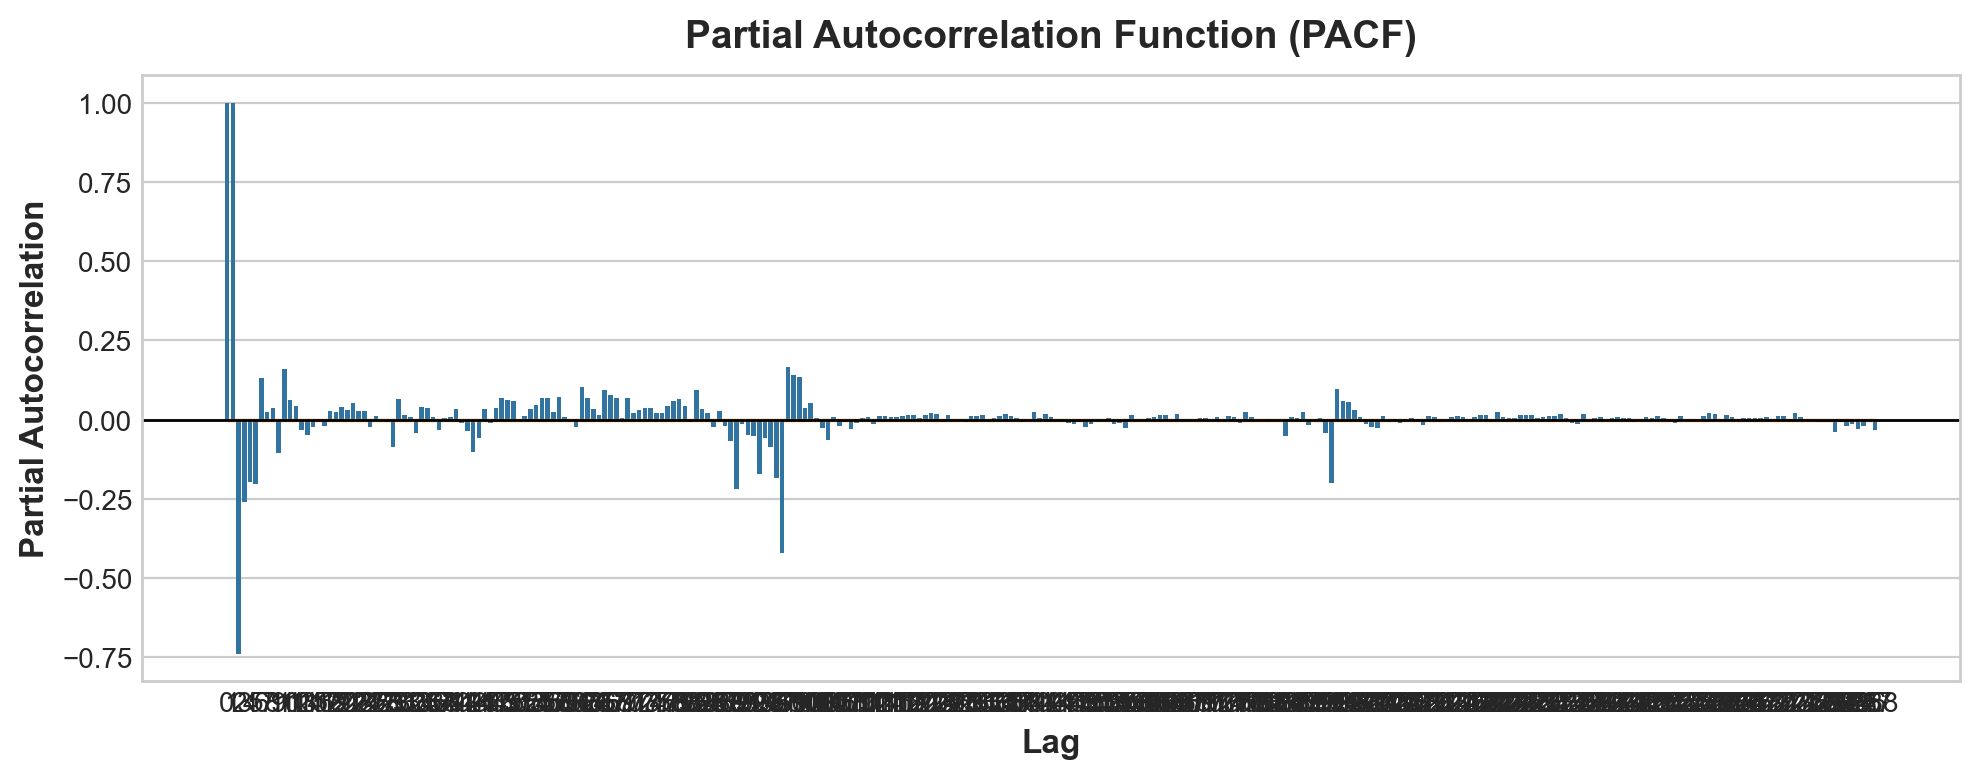

In [460]:
plot_pacf(data['Actual Total Load (MW)'], lags=72*4)

In [203]:
X1 = make_lags(y_deseasoned_fit, 24*4+1, 24*4+8).fillna(0.0)
X2 = make_lags(y_deseasoned_fit, 48*4+1, 48*4+8).fillna(0.0)
X3 = make_lags(y_deseasoned_fit, 72*4+1, 72*4+8).fillna(0.0)

In [210]:
Y = make_lags(y_deseasoned_fit, -24*4+1, 0).fillna(0.0)

In [205]:
x1 = make_lags(y_deseasoned_pred, 24*4+1, 24*4+8).fillna(0.0)
x2 = make_lags(y_deseasoned_pred, 48*4+1, 48*4+8).fillna(0.0)
x3 = make_lags(y_deseasoned_pred, 72*4+1, 72*4+8).fillna(0.0)

In [211]:
X = pd.concat([X,X1,X2,X3], axis = 1).fillna(0.0)
X_test = pd.concat([X_test,x1,x2,x3], axis = 1).fillna(0.0)
y_resid = Y.fillna(0.0)

In [131]:
X

,y_lag_97,y_lag_98,y_lag_99,y_lag_100,y_lag_101,y_lag_102,y_lag_103,y_lag_104,y_lag_193,y_lag_194,...,y_lag_199,y_lag_200,y_lag_289,y_lag_290,y_lag_291,y_lag_292,y_lag_293,y_lag_294,y_lag_295,y_lag_296
2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 22:45:00,447.810743,445.499250,429.834409,138.909319,114.398002,143.414876,121.512134,115.975292,332.191355,376.949105,...,53.104777,88.377049,-2.506587,36.658680,35.689881,-260.450176,-258.554336,-267.106772,-230.953887,-216.701459
2024-12-30 23:00:00,424.482507,447.810743,445.499250,429.834409,138.909319,114.398002,143.414876,121.512134,332.157024,332.191355,...,44.079376,53.104777,-18.493733,-2.506587,36.658680,35.689881,-260.450176,-258.554336,-267.106772,-230.953887
2024-12-30 23:15:00,459.600601,424.482507,447.810743,445.499250,429.834409,138.909319,114.398002,143.414876,368.931270,332.157024,...,65.702175,44.079376,47.981868,-18.493733,-2.506587,36.658680,35.689881,-260.450176,-258.554336,-267.106772
2024-12-30 23:30:00,428.891383,459.600601,424.482507,447.810743,445.499250,429.834409,138.909319,114.398002,346.717607,368.931270,...,79.220026,65.702175,3.318296,47.981868,-18.493733,-2.506587,36.658680,35.689881,-260.450176,-258.554336


In [467]:
X['week'] = X.index.week
X['day'] = X.index.dayofweek
X_test['week'] = X_test.index.week
X_test['day'] = X_test.index.dayofweek

C:\Users\as comp\AppData\Local\Temp\ipykernel_10916\140117257.py:1: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  X['week'] = X.index.week
C:\Users\as comp\AppData\Local\Temp\ipykernel_10916\140117257.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  X_test['week'] = X_test.index.week


In [208]:
X_train, y_pred = X_train.align(y_pred, join='inner', axis = 0)

In [209]:
y_resid = pd.DataFrame(y_resid)

In [212]:
y_resid

,y_lag_-95,y_lag_-94,y_lag_-93,y_lag_-92,y_lag_-91,y_lag_-90,y_lag_-89,y_lag_-88,y_lag_-87,y_lag_-86,...,y_lag_-9,y_lag_-8,y_lag_-7,y_lag_-6,y_lag_-5,y_lag_-4,y_lag_-3,y_lag_-2,y_lag_-1,y_lag_0
2023-01-01 00:00:00,388.409292,365.381690,395.099404,433.273990,404.567616,432.707590,454.007851,423.154782,137.714649,106.288306,...,1052.049601,1077.871470,980.601093,996.700655,1019.417688,1012.388856,922.896711,897.580330,879.478593,836.328428
2023-01-01 00:15:00,-1327.762078,388.409292,365.381690,395.099404,433.273990,404.567616,432.707590,454.007851,423.154782,137.714649,...,1003.614016,1052.049601,1077.871470,980.601093,996.700655,1019.417688,1012.388856,922.896711,897.580330,879.478593
2023-01-01 00:30:00,-1333.487183,-1327.762078,388.409292,365.381690,395.099404,433.273990,404.567616,432.707590,454.007851,423.154782,...,951.506917,1003.614016,1052.049601,1077.871470,980.601093,996.700655,1019.417688,1012.388856,922.896711,897.580330
2023-01-01 00:45:00,-1337.807020,-1333.487183,-1327.762078,388.409292,365.381690,395.099404,433.273990,404.567616,432.707590,454.007851,...,914.013509,951.506917,1003.614016,1052.049601,1077.871470,980.601093,996.700655,1019.417688,1012.388856,922.896711
2023-01-01 01:00:00,-1354.458880,-1337.807020,-1333.487183,-1327.762078,388.409292,365.381690,395.099404,433.273990,404.567616,432.707590,...,829.240108,914.013509,951.506917,1003.614016,1052.049601,1077.871470,980.601093,996.700655,1019.417688,1012.388856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 22:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-158.080471,-165.373352,-132.674388,-95.471308,-113.296355
2024-12-30 23:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-158.080471,-165.373352,-132.674388,-95.471308
2024-12-30 23:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-158.080471,-165.373352,-132.674388
2024-12-30 23:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-158.080471,-165.373352


In [505]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"


In [474]:
from sklearn.multioutput import MultiOutputRegressor
xgb =XGBRegressor()
xgb.fit(X, y_resid)

y_fit1 = pd.Series(xgb.predict(X), index = X.index)
y_pred1 = pd.Series(xgb.predict(X_test), index = X_test.index)

In [177]:
# 1. select first row of every day (every 96 steps)
y_fit_daily = y_fit1.iloc[::96]
y_pred_daily = y_pred1.iloc[::96]

# 2. create time offsets for each 96-step 15-minute forecast
freq = '15T'
horizon = y_fit1.shape[1]
offsets = pd.timedelta_range(start='0T', periods=horizon, freq=freq)

# 3. convert rows into a timestamp-indexed Series
def expand_forecast(df):
    series_list = []
    for ts, row in df.iterrows():
        idx = ts + offsets
        s = pd.Series(row.values, index=idx)
        series_list.append(s)
    return pd.concat(series_list)

# 4. expanded series
y_fit1 = expand_forecast(y_fit_daily)
y_pred1 = expand_forecast(y_pred_daily)


In [475]:
y_fit_boosted = y_fit1 + y_fit
y_pred_boosted = y_pred1 + y_pred

C:\Users\as comp\AppData\Local\Temp\ipykernel_10916\1912794167.py:11: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  axs = y_pred_boosted.plot(


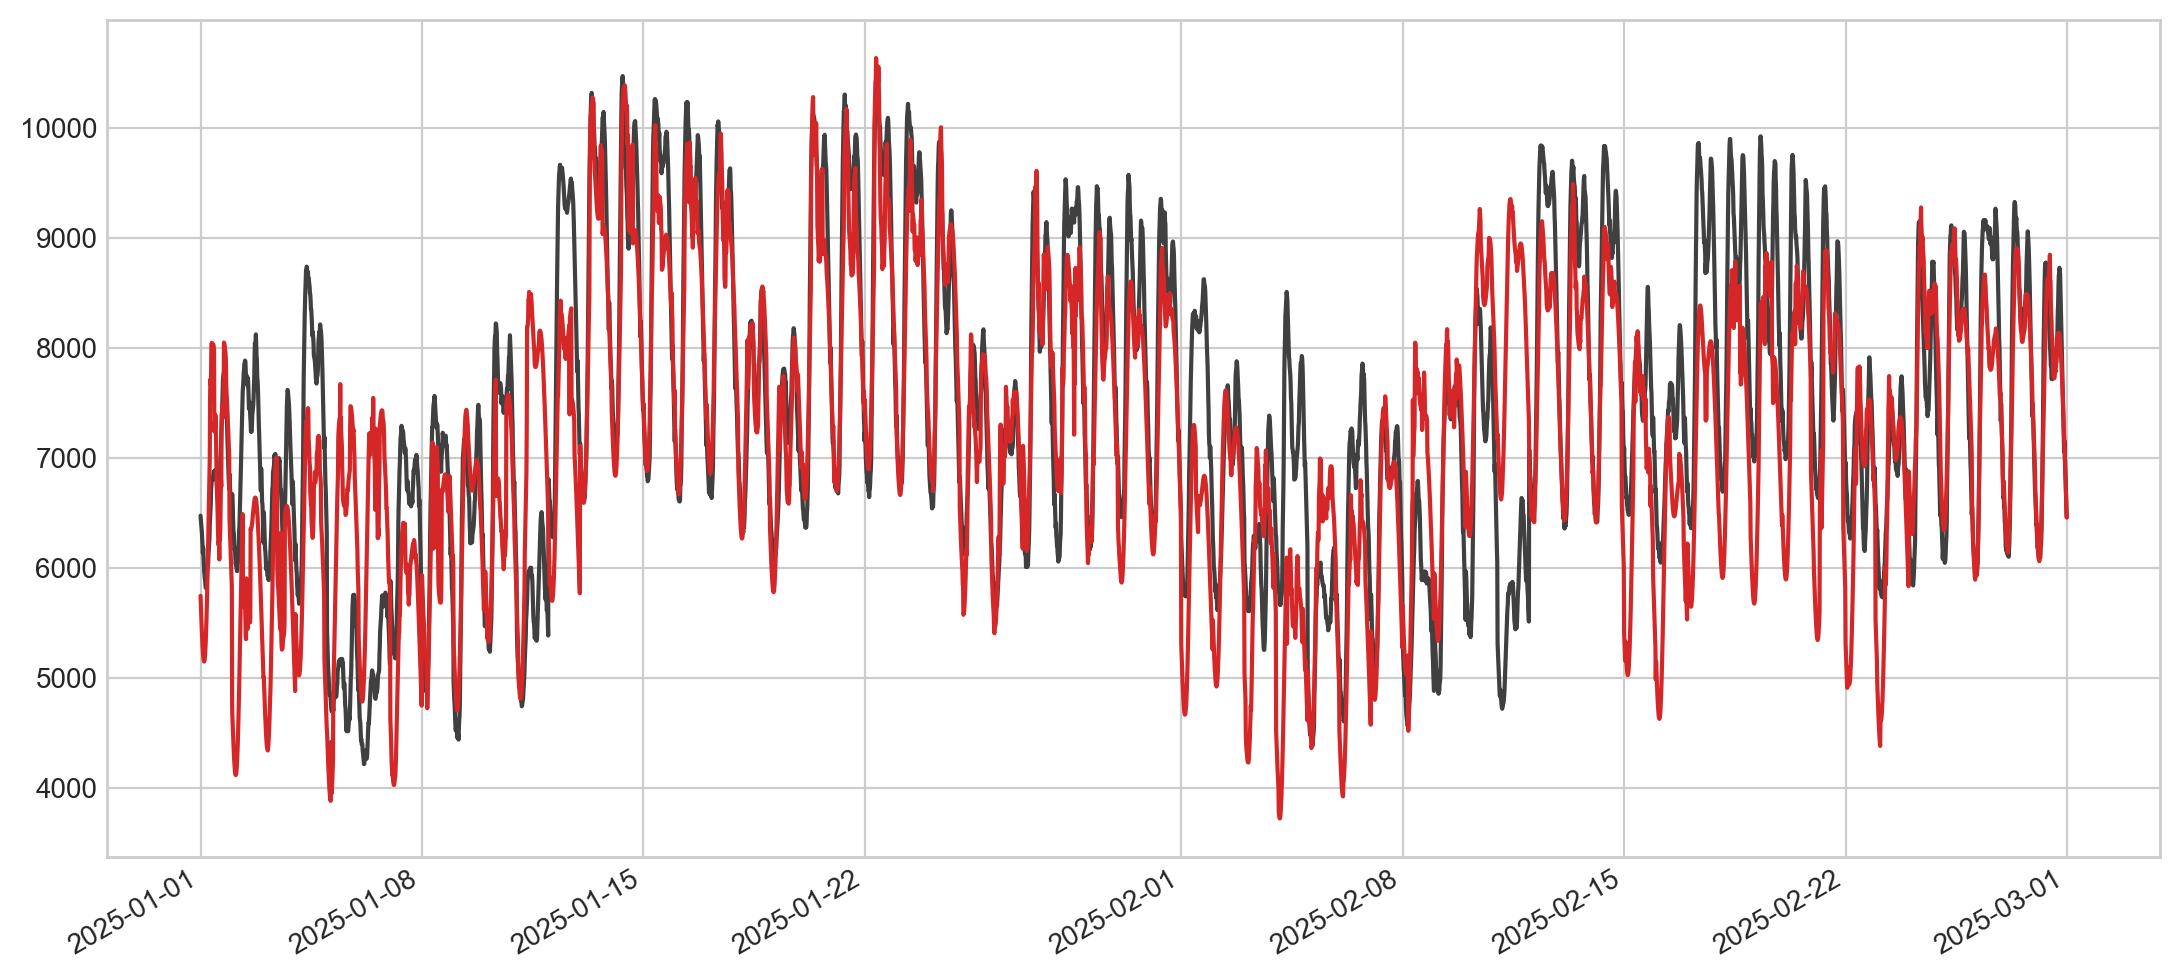

In [476]:
#axs = y.plot(
#    color='0.25', figsize=(11, 5), subplots=True, sharex=True,
#    title=['Hybrid Model Performance'],
#)
axs = y_test.plot(
    color='0.25', subplots=True, sharex=True, 
)
#axs = y_fit_boosted.plot(
#    color='C0', subplots=True, sharex=True, ax=axs,
#)
axs = y_pred_boosted.plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

In [180]:
y, y_fit_boosted = y.align(y_fit_boosted, join='inner', axis = 0)
y_test, y_pred_boosted = y_test.align(y_pred_boosted, join='inner', axis = 0)

In [477]:
print("Mean Absolute Error: " + str(mean_absolute_error(y, y_fit_boosted)))

Mean Absolute Error: 308.82931579933245


In [491]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_pred_boosted, y_test)))

Mean Absolute Error: 687.6617367872777
